# Восстановление характеристик полярных циклонов по спутниковым данным Sentinel-3 SLSTR

**Выпускная квалификационная работа:**  
«Восстановление и анализ характеристик и траекторий полярных циклонов по данным дистанционного зондирования Земли»

**Автор:** Соловьева Яна Сергеевна  
**Факультет:** факультет географии и геоинформационных технологий, НИУ ВШЭ  
**Образовательная программа:** «География глобальных изменений и геоинформационные технологии»  
**Направление подготовки:** 05.03.02 «География»

## Назначение ноутбука

Этот ноутбук содержит пайплайн подготовки данных, обучения и оценки регрессионной модели для восстановления характеристик полярных циклонов по спутниковым фрагментам Sentinel-3 SLSTR.

Основная задача модели — восстановление центрального давления циклона по изображению и дополнительным контекстным признакам. В качестве вспомогательной характеристики также рассматривается сглаженная относительная завихренность на уровне 850 гПа.

Пайплайн включает несколько этапов:

1. загрузку библиотек, путей и рабочих настроек;
2. подготовку функций для чтения снимков, нормализации данных, построения модели и расчета метрик;
3. загрузку таблицы обучающей выборки и спутниковых фрагментов;
4. обучение регрессионной модели;
5. оценку качества восстановления давления;
6. диагностику распределения целевых переменных;
7. просмотр отдельных примеров и интерпретацию результатов.

## Импорты библиотек, подготовка даннных, модель восстановления

In [1]:
# ячейка 1
# импорты, пути, настройки

!pip -q install tensorflow scikit-learn pillow openpyxl tqdm

from google.colab import drive
import contextlib
import io

with contextlib.redirect_stdout(io.StringIO()):
    drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from IPython.display import display

warnings.filterwarnings("ignore")

base_dir = Path("/content/drive/MyDrive/sentinel3/SLSTR")
project_dir = base_dir / "Solovieva_diploma_project"
dataset_path = project_dir / "Solovieva_diploma_PL_training_dataset.csv"

if not dataset_path.exists():
    raise FileNotFoundError(f"не найдена таблица: {dataset_path}")

img_size = 128
random_state = 42

split_test_size = 0.20
split_valid_size = 0.20
split_valid_from_trainvalid = split_valid_size / (1.0 - split_test_size)
split_candidate_seeds = list(range(1500))

batch_size = 16

# changed in fixed
epochs = 250
early_stop_patience = 12
learning_rate = 1e-4

use_online_augmentation = True

# added in fixed
use_mixup = True
mixup_alpha = 0.2

use_context_features = True
context_feature_names = ["lat_norm", "lon_sin", "lon_cos", "month_sin", "month_cos"]
n_context_features = len(context_feature_names)

use_linear_calibration = True
max_oversample_multiplier = 9

tf.keras.utils.set_random_seed(random_state)
np.random.seed(random_state)

In [2]:
# ячейка 2
# функции

def squeeze_to_2d(arr, path):
    arr = np.asarray(arr)

    if arr.ndim == 2:
        return arr

    if arr.ndim == 3:
        arr = np.squeeze(arr)

        if arr.ndim == 2:
            return arr

        if arr.shape[-1] in [1, 3, 4]:
            return arr[..., 0]

        if arr.shape[0] in [1, 3, 4]:
            return arr[0]

    raise ValueError(f"ожидался 2d crop, получено shape={arr.shape}, path={path}")


def prepare_crop_array(path, img_size=128):
    arr = np.load(path, allow_pickle=False).astype(np.float32)
    arr = squeeze_to_2d(arr, path)

    valid_mask = np.isfinite(arr)
    valid_fraction = float(valid_mask.mean())

    if valid_fraction <= 0:
        raise ValueError("в crop нет валидных пикселей")

    valid_values = arr[valid_mask]
    fill_value = float(np.nanmedian(valid_values))

    arr = np.where(np.isfinite(arr), arr, fill_value).astype(np.float32)

    if float(np.nanmedian(arr)) > 100:
        arr = np.clip(arr, 180.0, 330.0).astype(np.float32)

    original_shape = arr.shape

    image = Image.fromarray(arr.astype(np.float32))
    image = image.resize((img_size, img_size), resample=Image.BILINEAR)

    out = np.asarray(image).astype(np.float32)
    out = out[..., np.newaxis]

    crop_stats = {
        "computed_valid_fraction": valid_fraction,
        "original_crop_shape": str(original_shape),
        "raw_bt_min": float(np.nanmin(valid_values)),
        "raw_bt_p1": float(np.nanpercentile(valid_values, 1)),
        "raw_bt_p5": float(np.nanpercentile(valid_values, 5)),
        "raw_bt_mean": float(np.nanmean(valid_values)),
        "raw_bt_std": float(np.nanstd(valid_values)),
        "raw_bt_median": float(np.nanmedian(valid_values)),
        "raw_bt_p95": float(np.nanpercentile(valid_values, 95)),
        "raw_bt_p99": float(np.nanpercentile(valid_values, 99)),
        "raw_bt_max": float(np.nanmax(valid_values)),
        "raw_bt_range": float(np.nanmax(valid_values) - np.nanmin(valid_values)),
    }

    return out, crop_stats


def extract_context_features(metadata_df):
    lat = pd.to_numeric(metadata_df["lat"], errors="coerce").values.astype(np.float32)
    lon = pd.to_numeric(metadata_df["lon"], errors="coerce").values.astype(np.float32)

    obs_dt = pd.to_datetime(metadata_df["obs_datetime"], errors="coerce")
    month = obs_dt.dt.month.fillna(6).values.astype(np.float32)

    lat_med = np.nanmedian(lat[np.isfinite(lat)]) if np.isfinite(lat).any() else 70.0
    lat = np.where(np.isfinite(lat), lat, lat_med)
    lon = np.where(np.isfinite(lon), lon, 0.0)

    lat_norm = (lat - 70.0) / 15.0

    lon_rad = np.deg2rad(lon)
    month_rad = 2 * np.pi * (month - 1) / 12.0

    features = np.stack(
        [
            lat_norm,
            np.sin(lon_rad),
            np.cos(lon_rad),
            np.sin(month_rad),
            np.cos(month_rad),
        ],
        axis=1,
    )

    return features.astype(np.float32)


def build_pressure_cnn_v3(
    input_shape=(128, 128, 1),
    n_context_features=5,
    use_context_features=True,
    output_name="target",
    output_bias=0.0,
    huber_delta=5.0,
):
    image_input = layers.Input(shape=input_shape, name="image")

    x = layers.Conv2D(16, 3, padding="same", use_bias=False)(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(96, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)

    if use_context_features:
        context_input = layers.Input(shape=(n_context_features,), name="context")

        c = layers.Dense(16, activation="relu")(context_input)
        c = layers.Dropout(0.10)(c)

        z = layers.Concatenate()([x, c])
        z = layers.Dense(64, activation="relu")(z)
        z = layers.Dropout(0.20)(z)
        z = layers.Dense(32, activation="relu")(z)

        output = layers.Dense(
            1,
            name=output_name,
            bias_initializer=keras.initializers.Constant(output_bias),
        )(z)

        model = keras.Model(inputs=[image_input, context_input], outputs=output)

    else:
        z = layers.Dense(64, activation="relu")(x)
        z = layers.Dropout(0.20)(z)
        z = layers.Dense(32, activation="relu")(z)

        output = layers.Dense(
            1,
            name=output_name,
            bias_initializer=keras.initializers.Constant(output_bias),
        )(z)

        model = keras.Model(inputs=image_input, outputs=output)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.Huber(delta=huber_delta),
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

    return model


class TargetMetricsCallback(keras.callbacks.Callback):
    def __init__(
        self,
        x_train_data,
        c_train_data,
        y_train_true,
        x_valid_data,
        c_valid_data,
        y_valid_true,
        baseline_valid_mae,
        output_bias=None,
        use_log_target=False,
    ):
        super().__init__()

        self.x_train_data = tf.convert_to_tensor(x_train_data.astype(np.float32))
        self.c_train_data = tf.convert_to_tensor(c_train_data.astype(np.float32)) if c_train_data is not None else None
        self.y_train_true = y_train_true.flatten().astype(np.float32)

        self.x_valid_data = tf.convert_to_tensor(x_valid_data.astype(np.float32))
        self.c_valid_data = tf.convert_to_tensor(c_valid_data.astype(np.float32)) if c_valid_data is not None else None
        self.y_valid_true = y_valid_true.flatten().astype(np.float32)

        self.baseline_valid_mae = float(baseline_valid_mae)
        self.output_bias = float(output_bias) if output_bias is not None else None

        self.best_val_mae_target = np.inf
        self.epochs_without_improvement = 0
        self.use_log_target = use_log_target

    def _eval(self, x, c, y_true):
        if c is not None:
            y_pred = self.model([x, c], training=False).numpy().flatten()
        else:
            y_pred = self.model(x, training=False).numpy().flatten()

        if self.use_log_target:
            y_pred = np.exp(y_pred)

        mae = mean_absolute_error(y_true, y_pred)
        rmse = math.sqrt(mean_squared_error(y_true, y_pred))
        pred_mean = float(y_pred.mean())
        pred_std = float(y_pred.std())

        return float(mae), float(rmse), pred_mean, pred_std

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_mae, train_rmse, train_pred_mean, train_pred_std = self._eval(
            self.x_train_data, self.c_train_data, self.y_train_true
        )
        val_mae, val_rmse, val_pred_mean, val_pred_std = self._eval(
            self.x_valid_data, self.c_valid_data, self.y_valid_true
        )

        logs["train_mae_target"] = train_mae
        logs["train_rmse_target"] = train_rmse
        logs["val_mae_target"] = val_mae
        logs["val_rmse_target"] = val_rmse

        if val_mae < self.best_val_mae_target - 0.05:
            self.best_val_mae_target = val_mae
            self.epochs_without_improvement = 0
        else:
            self.epochs_without_improvement += 1

        gap = val_mae - train_mae
        improvement_pct = (self.baseline_valid_mae - val_mae) / self.baseline_valid_mae * 100

        if self.output_bias is not None:
            stuck_at_bias = (
                abs(val_pred_mean - self.output_bias) < 0.5
                and val_pred_std < 0.5
            )
        else:
            stuck_at_bias = False

        if stuck_at_bias:
            status = "застряла на стартовом bias"
        elif improvement_pct < 0:
            status = f"хуже baseline ({-improvement_pct:.0f}% хуже среднего)"
        elif improvement_pct < 2:
            status = f"почти не учится (улучшение {improvement_pct:.1f}% от baseline)"
        elif gap > 4.0 and train_mae < val_mae:
            status = f"переобучение (val лучше на {improvement_pct:.0f}%, gap {gap:+.1f})"
        elif gap > 2.5 and train_mae < val_mae:
            status = f"легкий overfit (val лучше на {improvement_pct:.0f}%, gap {gap:+.1f})"
        else:
            status = f"учится, улучшение {improvement_pct:.0f}% от baseline"

        no_improve_flag = ""
        if self.epochs_without_improvement >= 10:
            no_improve_flag = f" | без улучшения {self.epochs_without_improvement} эп."

        print(
            f"\n   train_mae: {train_mae:6.2f} | val_mae: {val_mae:6.2f} | "
            f"gap: {gap:+5.2f} | best: {self.best_val_mae_target:.2f} | "
            f"pred_std val: {val_pred_std:5.2f} | {status}{no_improve_flag}"
        )


def fit_linear_calibration(y_valid_true, y_valid_pred):
    y_valid_true = np.asarray(y_valid_true).reshape(-1)
    y_valid_pred = np.asarray(y_valid_pred).reshape(-1)

    reg = LinearRegression()
    reg.fit(y_valid_pred.reshape(-1, 1), y_valid_true)

    a = float(reg.coef_[0])
    b = float(reg.intercept_)

    return a, b


def apply_linear_calibration(y_pred, a, b):
    y_pred = np.asarray(y_pred).reshape(-1)
    return a * y_pred + b


def resolve_npy_path(row):
    rel = row.get("npy_relative_path", np.nan)

    if pd.notna(rel) and str(rel).strip() not in ["", "<NA>", "nan", "None"]:
        p = project_dir / str(rel)
        if p.exists():
            return p

    raw = row.get("npy_path", np.nan)

    if pd.notna(raw) and str(raw).strip() not in ["", "<NA>", "nan", "None"]:
        p = Path(str(raw))
        if p.exists():
            return p

    return None


def make_mixup_fn(mixup_alpha=0.2, use_context=True):
    def sample_beta_distribution(size, alpha):
        gamma_1 = tf.random.gamma(shape=[size], alpha=alpha)
        gamma_2 = tf.random.gamma(shape=[size], alpha=alpha)
        return gamma_1 / (gamma_1 + gamma_2)

    def mixup_batch_with_context(inputs, y_target):
        x_img, c_feat = inputs
        batch_size_dynamic = tf.shape(x_img)[0]

        lam = sample_beta_distribution(batch_size_dynamic, mixup_alpha)
        lam = tf.maximum(lam, 1.0 - lam)

        perm = tf.random.shuffle(tf.range(batch_size_dynamic))

        lam_img = tf.reshape(lam, [-1, 1, 1, 1])
        x_mixed = lam_img * x_img + (1.0 - lam_img) * tf.gather(x_img, perm)

        lam_ctx = tf.reshape(lam, [-1, 1])
        c_mixed = lam_ctx * c_feat + (1.0 - lam_ctx) * tf.gather(c_feat, perm)

        y_flat = tf.reshape(y_target, [-1])
        y_mixed = lam * y_flat + (1.0 - lam) * tf.gather(y_flat, perm)
        y_mixed = tf.reshape(y_mixed, [-1, 1])

        return (x_mixed, c_mixed), y_mixed

    def mixup_batch_no_context(x_img, y_target):
        batch_size_dynamic = tf.shape(x_img)[0]

        lam = sample_beta_distribution(batch_size_dynamic, mixup_alpha)
        lam = tf.maximum(lam, 1.0 - lam)

        perm = tf.random.shuffle(tf.range(batch_size_dynamic))

        lam_img = tf.reshape(lam, [-1, 1, 1, 1])
        x_mixed = lam_img * x_img + (1.0 - lam_img) * tf.gather(x_img, perm)

        y_flat = tf.reshape(y_target, [-1])
        y_mixed = lam * y_flat + (1.0 - lam) * tf.gather(y_flat, perm)
        y_mixed = tf.reshape(y_mixed, [-1, 1])

        return x_mixed, y_mixed

    if use_context:
        return mixup_batch_with_context

    return mixup_batch_no_context

In [3]:
# ячейка 3
# загрузка training dataset + снимков

dataset = pd.read_csv(dataset_path, dtype={"ID": str})

required_cols = [
    "ID",
    "step",
    "datetime",
    "lat",
    "lon",
    "slp",
    "rel_vort_850_smth",
    "npy_relative_path",
]

missing_cols = [c for c in required_cols if c not in dataset.columns]

if missing_cols:
    raise ValueError(f"в таблице не найдены колонки: {missing_cols}")

dataset["ID"] = dataset["ID"].astype(str)
dataset["step"] = pd.to_numeric(dataset["step"], errors="coerce")
dataset["obs_datetime"] = pd.to_datetime(dataset["datetime"], errors="coerce")
dataset["lat"] = pd.to_numeric(dataset["lat"], errors="coerce")
dataset["lon"] = pd.to_numeric(dataset["lon"], errors="coerce")
dataset["slp"] = pd.to_numeric(dataset["slp"], errors="coerce")
dataset["rel_vort_850_smth"] = pd.to_numeric(dataset["rel_vort_850_smth"], errors="coerce")

dataset["resolved_crop_path_npy"] = dataset.apply(resolve_npy_path, axis=1)

before = len(dataset)

dataset_ml = dataset[
    dataset["resolved_crop_path_npy"].notna()
    & dataset["slp"].notna()
    & dataset["rel_vort_850_smth"].notna()
    & dataset["lat"].notna()
    & dataset["lon"].notna()
    & dataset["obs_datetime"].notna()
].copy()

dataset_ml = dataset_ml.reset_index(drop=True)

print("строк в исходной таблице:", before)
print("строк после фильтрации:", len(dataset_ml))
print("уникальных ID после фильтрации:", dataset_ml["ID"].nunique())

if len(dataset_ml) == 0:
    raise ValueError("после фильтрации не осталось строк")

images = []
stats_rows = []
bad_rows = []

for i, row in tqdm(dataset_ml.iterrows(), total=len(dataset_ml), desc="загрузка crop"):
    path = row["resolved_crop_path_npy"]

    try:
        img, stats = prepare_crop_array(path, img_size=img_size)
        images.append(img)

        stats["row_index"] = i
        stats["resolved_crop_path_npy"] = str(path)
        stats_rows.append(stats)

    except Exception as e:
        bad_rows.append(
            {
                "row_index": i,
                "ID": row["ID"],
                "step": row["step"],
                "path": str(path),
                "error": repr(e),
            }
        )

if bad_rows:
    bad_df = pd.DataFrame(bad_rows)
    print("ошибочных crop:", len(bad_df))
    display(bad_df.head(20))

    good_indices = sorted(set(range(len(dataset_ml))) - set(bad_df["row_index"].tolist()))
    dataset_ml = dataset_ml.iloc[good_indices].reset_index(drop=True)

else:
    good_indices = list(range(len(dataset_ml)))

X = np.stack([images[i] for i in range(len(images))], axis=0).astype(np.float32)

stats_df = pd.DataFrame(stats_rows).reset_index(drop=True)

metadata_ml = pd.concat(
    [
        dataset_ml.reset_index(drop=True),
        stats_df.drop(columns=["row_index"], errors="ignore"),
    ],
    axis=1,
)

print("X shape:", X.shape)
print("metadata_ml shape:", metadata_ml.shape)

display(
    metadata_ml[
        [
            "ID",
            "step",
            "obs_datetime",
            "lat",
            "lon",
            "slp",
            "rel_vort_850_smth",
            "computed_valid_fraction",
            "raw_bt_mean",
            "raw_bt_std",
            "raw_bt_min",
            "raw_bt_max",
        ]
    ].head()
)

display(
    pd.DataFrame(
        {
            "показатель": [
                "число снимков",
                "число ID",
                "slp min",
                "slp mean",
                "slp max",
                "slp std",
                "rel_vort min",
                "rel_vort mean",
                "rel_vort max",
                "rel_vort std",
            ],
            "значение": [
                len(metadata_ml),
                metadata_ml["ID"].nunique(),
                metadata_ml["slp"].min(),
                metadata_ml["slp"].mean(),
                metadata_ml["slp"].max(),
                metadata_ml["slp"].std(),
                metadata_ml["rel_vort_850_smth"].min(),
                metadata_ml["rel_vort_850_smth"].mean(),
                metadata_ml["rel_vort_850_smth"].max(),
                metadata_ml["rel_vort_850_smth"].std(),
            ],
        }
    )
)

строк в исходной таблице: 578
строк после фильтрации: 578
уникальных ID после фильтрации: 209


загрузка crop:   0%|          | 0/578 [00:00<?, ?it/s]

X shape: (578, 128, 128, 1)
metadata_ml shape: (578, 33)


,ID,step,obs_datetime,lat,lon,slp,rel_vort_850_smth,computed_valid_fraction,raw_bt_mean,raw_bt_std,raw_bt_min,raw_bt_max
0,120200107090,35,2020-01-12 14:00:00,66.50,-3.00,970.90997,24.223,1.0,264.895081,9.481275,231.839996,277.140015
1,120200107090,35,2020-01-12 14:00:00,66.50,-3.00,970.90997,24.223,1.0,264.895081,9.481275,231.839996,277.140015
2,120200107090,36,2020-01-12 15:00:00,66.75,-2.00,971.16058,25.625,1.0,264.895081,9.481275,231.839996,277.140015
3,120200107090,43,2020-01-12 22:00:00,68.50,2.75,972.18060,28.182,1.0,248.765915,13.633680,212.630005,278.579987
4,120200107090,44,2020-01-12 23:00:00,68.50,2.75,973.16125,28.549,1.0,248.382385,13.578097,212.869995,278.390015


,показатель,значение
0,число снимков,578.000000
1,число ID,209.000000
2,slp min,957.075620
3,slp mean,989.357473
4,slp max,1021.234380
5,slp std,11.060706
6,rel_vort min,15.096000
7,rel_vort mean,25.213197
8,rel_vort max,56.956000
9,rel_vort std,7.559836


In [4]:
# ячейка 4
# полный пайплайн обучения и оценки регрессионной модели

def run_one_target(
    X,
    metadata_ml,
    target_col,
    target_label,
    target_units,
    target_bin_edges,
    target_bin_labels,
):
    tf.keras.utils.set_random_seed(random_state)
    np.random.seed(random_state)

    y = metadata_ml[target_col].values.astype(np.float32).reshape(-1, 1)
    target_bin_edges = np.asarray(target_bin_edges, dtype=float)

    # ДОБАВЛЕНО для завихренности: log-трансформация target

    # завихренность имеет сильный правый хвост, поэтому обучаю модель
    # на log(y), а метрики считаю обратно в исходных единицах.
    # для давления log-transform не используется.

    if target_col == "rel_vort_850_smth":
        use_log_target_local = True
        huber_delta_local = 2.0
        mixup_alpha_local = 0.0
        use_mixup_local = False
        print(f"\n[адаптация для {target_col}] log-target=True, delta=2.0, mixup=OFF")
    else:
        use_log_target_local = False
        huber_delta_local = 5.0
        mixup_alpha_local = mixup_alpha
        use_mixup_local = use_mixup

    def target_bins(values):
        values = np.asarray(values).reshape(-1)
        bins = np.digitize(values, target_bin_edges) - 1
        bins = np.clip(bins, 0, len(target_bin_edges) - 2)
        return bins.astype(int)

    def can_use_stratify(labels):
        labels = np.asarray(labels)

        if len(labels) == 0:
            return False

        _, counts = np.unique(labels, return_counts=True)

        if len(counts) < 2:
            return False

        return counts.min() >= 2

    def bin_props(values):
        values = np.asarray(values).reshape(-1)
        counts = np.histogram(values, bins=target_bin_edges)[0].astype(float)

        if counts.sum() == 0:
            return np.zeros_like(counts)

        return counts / counts.sum()

    def make_group_table(metadata_df, y_array):
        tmp = metadata_df.copy()
        tmp["_sample_index"] = np.arange(len(tmp))
        tmp["_target"] = y_array.reshape(-1)

        group_table = (
            tmp
            .groupby("ID")
            .agg(
                n_samples=("_sample_index", "size"),
                y_mean=("_target", "mean"),
                y_min=("_target", "min"),
                y_max=("_target", "max"),
                y_std=("_target", "std"),
            )
            .reset_index()
        )

        group_table["y_std"] = group_table["y_std"].fillna(0)
        group_table["target_bin"] = target_bins(group_table["y_mean"].values)

        return group_table

    def group_ids_to_sample_indices(group_ids, metadata_df):
        group_ids = set([str(x) for x in group_ids])
        idx = metadata_df.index[metadata_df["ID"].astype(str).isin(group_ids)].to_numpy()
        return idx.astype(int)

    def try_one_group_split(group_table, seed):
        group_ids_all = group_table["ID"].astype(str).values
        group_bins_all = group_table["target_bin"].values

        stratify_first = group_bins_all if can_use_stratify(group_bins_all) else None

        trainvalid_groups, test_groups = train_test_split(
            group_ids_all,
            test_size=split_test_size,
            random_state=seed,
            stratify=stratify_first,
        )

        trainvalid_info = group_table.set_index("ID").loc[trainvalid_groups].reset_index()
        trainvalid_bins = trainvalid_info["target_bin"].values

        stratify_second = trainvalid_bins if can_use_stratify(trainvalid_bins) else None

        train_groups, valid_groups = train_test_split(
            trainvalid_groups,
            test_size=split_valid_from_trainvalid,
            random_state=seed + 10000,
            stratify=stratify_second,
        )

        return train_groups, valid_groups, test_groups

    def split_score(train_idx, valid_idx, test_idx, y_all):
        y_all_f = y_all.reshape(-1)
        y_tr = y_all_f[train_idx]
        y_va = y_all_f[valid_idx]
        y_te = y_all_f[test_idx]

        all_mean = float(np.mean(y_all_f))
        all_std = float(np.std(y_all_f))
        all_range = float(np.max(y_all_f) - np.min(y_all_f))

        tr_min, tr_max = float(np.min(y_tr)), float(np.max(y_tr))
        te_min, te_max = float(np.min(y_te)), float(np.max(y_te))
        va_min, va_max = float(np.min(y_va)), float(np.max(y_va))

        outside_test = max(0.0, tr_min - te_min) + max(0.0, te_max - tr_max)
        outside_valid = max(0.0, tr_min - va_min) + max(0.0, va_max - tr_max)

        test_range = te_max - te_min
        valid_range = va_max - va_min

        narrow_test = max(0.0, 0.55 * all_range - test_range)
        narrow_valid = max(0.0, 0.55 * all_range - valid_range)

        p_all = bin_props(y_all_f)
        p_tr = bin_props(y_tr)
        p_va = bin_props(y_va)
        p_te = bin_props(y_te)

        bin_dist = (
            np.abs(p_tr - p_all).sum()
            + np.abs(p_va - p_all).sum()
            + np.abs(p_te - p_all).sum()
        )

        mean_dist = (
            abs(float(np.mean(y_tr)) - all_mean)
            + abs(float(np.mean(y_va)) - all_mean)
            + abs(float(np.mean(y_te)) - all_mean)
        )

        std_dist = (
            abs(float(np.std(y_tr)) - all_std)
            + abs(float(np.std(y_va)) - all_std)
            + abs(float(np.std(y_te)) - all_std)
        )

        n = len(y_all_f)

        size_dist = (
            abs(len(train_idx) / n - 0.60)
            + abs(len(valid_idx) / n - 0.20)
            + abs(len(test_idx) / n - 0.20)
        )

        score = (
            100.0 * outside_test
            + 60.0 * outside_valid
            + 10.0 * narrow_test
            + 7.0 * narrow_valid
            + 25.0 * bin_dist
            + 0.40 * mean_dist
            + 0.70 * std_dist
            + 50.0 * size_dist
        )

        details = {
            "score": float(score),
            "outside_test": float(outside_test),
            "outside_valid": float(outside_valid),
            "narrow_test": float(narrow_test),
            "narrow_valid": float(narrow_valid),
            "bin_dist": float(bin_dist),
            "mean_dist": float(mean_dist),
            "std_dist": float(std_dist),
            "size_dist": float(size_dist),
            "train_min": float(tr_min),
            "train_max": float(tr_max),
            "valid_min": float(va_min),
            "valid_max": float(va_max),
            "test_min": float(te_min),
            "test_max": float(te_max),
            "train_std": float(np.std(y_tr)),
            "valid_std": float(np.std(y_va)),
            "test_std": float(np.std(y_te)),
            "train_mean": float(np.mean(y_tr)),
            "valid_mean": float(np.mean(y_va)),
            "test_mean": float(np.mean(y_te)),
            "n_train": int(len(train_idx)),
            "n_valid": int(len(valid_idx)),
            "n_test": int(len(test_idx)),
        }

        return float(score), details

    metadata_ml = metadata_ml.copy().reset_index(drop=True)
    metadata_ml["ID"] = metadata_ml["ID"].astype(str)

    group_table = make_group_table(metadata_ml, y)
    group_bin_counts = group_table["target_bin"].value_counts().sort_index()

    display(
        pd.DataFrame(
            {
                "показатель": [
                    "целевая переменная",
                    "число ID",
                    "число снимков",
                    "min",
                    "mean",
                    "max",
                    "std",
                ],
                "значение": [
                    target_label,
                    len(group_table),
                    len(metadata_ml),
                    float(y.min()),
                    float(y.mean()),
                    float(y.max()),
                    float(y.std()),
                ],
            }
        )
    )

    display(
        pd.DataFrame(
            {
                "диапазон": target_bin_labels,
                "число ID": [
                    int(group_bin_counts.get(i, 0))
                    for i in range(len(target_bin_labels))
                ],
            }
        )
    )

    best = None
    all_split_attempts = []

    if len(group_table) >= 8:
        for seed in split_candidate_seeds:
            try:
                train_groups, valid_groups, test_groups = try_one_group_split(group_table, seed)

                train_idx = group_ids_to_sample_indices(train_groups, metadata_ml)
                valid_idx = group_ids_to_sample_indices(valid_groups, metadata_ml)
                test_idx = group_ids_to_sample_indices(test_groups, metadata_ml)

                if len(train_idx) == 0 or len(valid_idx) == 0 or len(test_idx) == 0:
                    continue

                score, details = split_score(train_idx, valid_idx, test_idx, y)

                details["seed"] = seed
                all_split_attempts.append(details)

                if best is None or score < best["score"]:
                    best = {
                        "score": score,
                        "seed": seed,
                        "train_idx": train_idx,
                        "valid_idx": valid_idx,
                        "test_idx": test_idx,
                        "details": details,
                    }

            except Exception:
                continue

    if best is None:
        indices = np.arange(len(X))
        sample_bins = target_bins(y.reshape(-1))

        strat_first = sample_bins if can_use_stratify(sample_bins) else None

        trainvalid_idx, test_idx = train_test_split(
            indices,
            test_size=split_test_size,
            random_state=random_state,
            stratify=strat_first,
        )

        trainvalid_bins = sample_bins[trainvalid_idx]
        strat_second = trainvalid_bins if can_use_stratify(trainvalid_bins) else None

        train_idx, valid_idx = train_test_split(
            trainvalid_idx,
            test_size=split_valid_from_trainvalid,
            random_state=random_state + 10000,
            stratify=strat_second,
        )

        score, details = split_score(train_idx, valid_idx, test_idx, y)

        best = {
            "score": score,
            "seed": random_state,
            "train_idx": train_idx,
            "valid_idx": valid_idx,
            "test_idx": test_idx,
            "details": details,
        }

    split_candidates_df = pd.DataFrame(all_split_attempts)

    if len(split_candidates_df) > 0:
        display(
            split_candidates_df
            .sort_values("score")
            .head(10)
            [
                [
                    "seed",
                    "score",
                    "n_train",
                    "n_valid",
                    "n_test",
                    "train_min",
                    "train_max",
                    "valid_min",
                    "valid_max",
                    "test_min",
                    "test_max",
                    "train_std",
                    "valid_std",
                    "test_std",
                    "outside_test",
                    "outside_valid",
                    "narrow_test",
                    "bin_dist",
                ]
            ]
        )

    train_idx = best["train_idx"]
    valid_idx = best["valid_idx"]
    test_idx = best["test_idx"]

    X_train = X[train_idx]
    y_train = y[train_idx]
    metadata_train = metadata_ml.iloc[train_idx].copy().reset_index(drop=True)

    X_valid = X[valid_idx]
    y_valid = y[valid_idx]
    metadata_valid = metadata_ml.iloc[valid_idx].copy().reset_index(drop=True)

    X_test = X[test_idx]
    y_test = y[test_idx]
    metadata_test = metadata_ml.iloc[test_idx].copy().reset_index(drop=True)

    metadata_train["split"] = "train"
    metadata_valid["split"] = "valid"
    metadata_test["split"] = "test"

    split_summary = pd.DataFrame(
        {
            "split": ["train", "valid", "test"],
            "samples": [len(X_train), len(X_valid), len(X_test)],
            "ID": [
                metadata_train["ID"].nunique(),
                metadata_valid["ID"].nunique(),
                metadata_test["ID"].nunique(),
            ],
            "min": [float(y_train.min()), float(y_valid.min()), float(y_test.min())],
            "mean": [float(y_train.mean()), float(y_valid.mean()), float(y_test.mean())],
            "max": [float(y_train.max()), float(y_valid.max()), float(y_test.max())],
            "std": [float(y_train.std()), float(y_valid.std()), float(y_test.std())],
        }
    )

    display(split_summary)

    train_ids = set(metadata_train["ID"].astype(str))
    valid_ids = set(metadata_valid["ID"].astype(str))
    test_ids = set(metadata_test["ID"].astype(str))

    display(
        pd.DataFrame(
            {
                "пересечение ID": ["train ∩ valid", "train ∩ test", "valid ∩ test"],
                "число": [
                    len(train_ids & valid_ids),
                    len(train_ids & test_ids),
                    len(valid_ids & test_ids),
                ],
            }
        )
    )

    def split_bin_table(y_train, y_valid, y_test):
        rows = []

        for split_name, yy in [
            ("train", y_train),
            ("valid", y_valid),
            ("test", y_test),
        ]:
            yy_flat = yy.reshape(-1)
            bins = target_bins(yy_flat)

            for i, label in enumerate(target_bin_labels):
                mask = bins == i

                rows.append(
                    {
                        "split": split_name,
                        "bin": label,
                        "n": int(mask.sum()),
                        "share": float(mask.mean()) if len(mask) > 0 else np.nan,
                        "target_min": float(yy_flat[mask].min()) if mask.sum() > 0 else np.nan,
                        "target_max": float(yy_flat[mask].max()) if mask.sum() > 0 else np.nan,
                    }
                )

        return pd.DataFrame(rows)

    bin_table = split_bin_table(y_train, y_valid, y_test)
    display(bin_table)

    x_train_mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
    x_train_std = X_train.std(axis=(0, 1, 2), keepdims=True)

    X_train_n = ((X_train - x_train_mean) / (x_train_std + 1e-8)).astype(np.float32)
    X_valid_n = ((X_valid - x_train_mean) / (x_train_std + 1e-8)).astype(np.float32)
    X_test_n = ((X_test - x_train_mean) / (x_train_std + 1e-8)).astype(np.float32)

    y_train_mean = float(y_train.mean())
    y_train_std = float(y_train.std())

    if y_train_std <= 0:
        raise ValueError("std у y_train равен 0")

    # ГЛАВНОЕ:
    # z-нормализация target убрана.
    # Давление обучается напрямую в гПа.
    # Для завихренности используется log-target.

    if use_log_target_local:
        y_train_n = np.log(y_train.astype(np.float32))
        y_valid_n = np.log(y_valid.astype(np.float32))
        y_test_n = np.log(y_test.astype(np.float32))

        y_train_mean_for_model = float(y_train_n.mean())
        y_train_std_for_model = float(y_train_n.std())
        output_bias_for_model = y_train_mean_for_model

        huber_delta_local = float(np.log1p(huber_delta_local / float(y_train.mean())))

        print(
            f"[log-target] y_train_mean log={y_train_mean_for_model:.3f}, "
            f"std log={y_train_std_for_model:.3f}, "
            f"Huber delta log={huber_delta_local:.4f}"
        )

    else:
        y_train_n = y_train.astype(np.float32)
        y_valid_n = y_valid.astype(np.float32)
        y_test_n = y_test.astype(np.float32)

        y_train_mean_for_model = y_train_mean
        y_train_std_for_model = y_train_std
        output_bias_for_model = y_train_mean

    baseline_valid_pred = np.full_like(y_valid.reshape(-1), y_train_mean)
    baseline_test_pred = np.full_like(y_test.reshape(-1), y_train_mean)

    baseline_valid_mae = float(mean_absolute_error(y_valid.reshape(-1), baseline_valid_pred))
    baseline_valid_rmse = float(math.sqrt(mean_squared_error(y_valid.reshape(-1), baseline_valid_pred)))

    baseline_test_mae = float(mean_absolute_error(y_test.reshape(-1), baseline_test_pred))
    baseline_test_rmse = float(math.sqrt(mean_squared_error(y_test.reshape(-1), baseline_test_pred)))

    display(
        pd.DataFrame(
            {
                "показатель": [
                    "x_mean",
                    "x_std",
                    "y_mean",
                    "y_std",
                    "valid baseline mae",
                    "valid baseline rmse",
                    "test baseline mae",
                    "test baseline rmse",
                ],
                "значение": [
                    float(x_train_mean.flatten()[0]),
                    float(x_train_std.flatten()[0]),
                    y_train_mean,
                    y_train_std,
                    baseline_valid_mae,
                    baseline_valid_rmse,
                    baseline_test_mae,
                    baseline_test_rmse,
                ],
            }
        )
    )

    if use_context_features:
        C_train_raw = extract_context_features(metadata_train)
        C_valid_raw = extract_context_features(metadata_valid)
        C_test_raw = extract_context_features(metadata_test)

        c_mean_use = C_train_raw.mean(axis=0, keepdims=True)
        c_std_use = C_train_raw.std(axis=0, keepdims=True) + 1e-8

        c_mean_use[0, 1:] = 0.0
        c_std_use[0, 1:] = 1.0

        C_train = ((C_train_raw - c_mean_use) / c_std_use).astype(np.float32)
        C_valid = ((C_valid_raw - c_mean_use) / c_std_use).astype(np.float32)
        C_test = ((C_test_raw - c_mean_use) / c_std_use).astype(np.float32)

    else:
        C_train = None
        C_valid = None
        C_test = None

    y_train_flat = y_train.reshape(-1)
    train_bin_idx = target_bins(y_train_flat)
    train_bin_counts = np.bincount(train_bin_idx, minlength=len(target_bin_labels))

    target_per_bin = int(train_bin_counts.max())

    oversample_map = {}

    for i in range(len(target_bin_labels)):
        count_i = int(train_bin_counts[i])

        if count_i == 0:
            multiplier = 0
        else:
            multiplier = int(np.ceil(target_per_bin / count_i))
            multiplier = max(1, multiplier)

        oversample_map[i] = multiplier

    balanced_indices = []

    for i in range(len(target_bin_labels)):
        idx_i = np.where(train_bin_idx == i)[0]
        multiplier = oversample_map[i]

        for _ in range(multiplier):
            balanced_indices.extend(idx_i.tolist())

    balanced_indices = np.array(balanced_indices, dtype=np.int64)

    X_balanced = X_train_n[balanced_indices].astype(np.float32)
    y_balanced = y_train_n[balanced_indices].astype(np.float32)

    if use_context_features:
        C_balanced = C_train[balanced_indices].astype(np.float32)
    else:
        C_balanced = None

    balanced_bin_idx = train_bin_idx[balanced_indices]

    is_rare_bin = np.array(
        [1.0 if oversample_map[int(b)] > 2 else 0.0 for b in balanced_bin_idx],
        dtype=np.float32,
    )

    balanced_counts = np.bincount(balanced_bin_idx, minlength=len(target_bin_labels))

    display(
        pd.DataFrame(
            {
                "диапазон": target_bin_labels,
                "train до oversampling": train_bin_counts,
                "множитель": [oversample_map[i] for i in range(len(target_bin_labels))],
                "train после oversampling": balanced_counts,
            }
        )
    )

    moderate_aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(factor=0.20, fill_mode="reflect"),
            layers.RandomTranslation(height_factor=0.035, width_factor=0.035, fill_mode="reflect"),
            layers.RandomZoom(height_factor=(-0.04, 0.04), width_factor=(-0.04, 0.04), fill_mode="reflect"),
            layers.GaussianNoise(0.012),
        ],
        name="moderate_aug",
    )

    strong_aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(factor=0.40, fill_mode="reflect"),
            layers.RandomTranslation(height_factor=0.060, width_factor=0.060, fill_mode="reflect"),
            layers.RandomZoom(height_factor=(-0.08, 0.08), width_factor=(-0.08, 0.08), fill_mode="reflect"),
            layers.GaussianNoise(0.020),
        ],
        name="strong_aug",
    )

    def augment_image_with_flag(x_img, rare_flag):
        x_img = tf.expand_dims(x_img, axis=0)

        if use_online_augmentation:
            x_img = tf.cond(
                rare_flag > 0.5,
                lambda: strong_aug(x_img, training=True),
                lambda: moderate_aug(x_img, training=True),
            )

        x_img = tf.squeeze(x_img, axis=0)
        return x_img

    n_aug_streams = 4

    if use_context_features:
        def augment_with_context(x_img, c_feat, y_target, rare_flag):
            x_img = augment_image_with_flag(x_img, rare_flag)
            return (x_img, c_feat), y_target

        base_train_ds = tf.data.Dataset.from_tensor_slices(
            (X_balanced, C_balanced, y_balanced, is_rare_bin)
        )

        train_ds = base_train_ds.map(augment_with_context, num_parallel_calls=tf.data.AUTOTUNE)

        for _ in range(n_aug_streams - 1):
            train_ds = train_ds.concatenate(
                base_train_ds.map(augment_with_context, num_parallel_calls=tf.data.AUTOTUNE)
            )

        valid_ds = (
            tf.data.Dataset.from_tensor_slices(
                (
                    (X_valid_n.astype(np.float32), C_valid.astype(np.float32)),
                    y_valid_n.astype(np.float32),
                )
            )
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

    else:
        def augment_without_context(x_img, y_target, rare_flag):
            x_img = augment_image_with_flag(x_img, rare_flag)
            return x_img, y_target

        base_train_ds = tf.data.Dataset.from_tensor_slices(
            (X_balanced, y_balanced, is_rare_bin)
        )

        train_ds = base_train_ds.map(augment_without_context, num_parallel_calls=tf.data.AUTOTUNE)

        for _ in range(n_aug_streams - 1):
            train_ds = train_ds.concatenate(
                base_train_ds.map(augment_without_context, num_parallel_calls=tf.data.AUTOTUNE)
            )

        valid_ds = (
            tf.data.Dataset.from_tensor_slices(
                (X_valid_n.astype(np.float32), y_valid_n.astype(np.float32))
            )
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

    train_samples_per_epoch = len(X_balanced) * n_aug_streams

    if use_mixup_local:
        mixup_fn = make_mixup_fn(mixup_alpha=mixup_alpha_local, use_context=use_context_features)

        train_ds = (
            train_ds
            .shuffle(
                buffer_size=train_samples_per_epoch,
                seed=random_state,
                reshuffle_each_iteration=True,
            )
            .batch(batch_size)
            .map(mixup_fn, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE)
        )

        print("\n[mixup] включен, alpha =", mixup_alpha_local)

    else:
        train_ds = (
            train_ds
            .shuffle(
                buffer_size=train_samples_per_epoch,
                seed=random_state,
                reshuffle_each_iteration=True,
            )
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

    plt.figure(figsize=(8, 4))
    plt.hist(y_train.reshape(-1), bins=25, alpha=0.55, label="train")
    plt.hist(y_valid.reshape(-1), bins=25, alpha=0.55, label="valid")
    plt.hist(y_test.reshape(-1), bins=25, alpha=0.55, label="test")
    plt.xlabel(target_label)
    plt.ylabel("число снимков")
    plt.title(f"Распределение целевой переменной по выборкам: {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(y_train.reshape(-1), bins=25, alpha=0.75)
    axes[0].set_title("train до oversampling")
    axes[0].set_xlabel(target_label)
    axes[0].grid(alpha=0.2)

    y_balanced_target = y_balanced.reshape(-1)

    if use_log_target_local:
        y_balanced_target = np.exp(y_balanced_target)

    axes[1].hist(y_balanced_target, bins=25, alpha=0.75)
    axes[1].set_title("train после oversampling")
    axes[1].set_xlabel(target_label)
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    n_examples = min(3, len(X_train_n))

    plt.figure(figsize=(12, 3 * n_examples))
    plot_i = 1

    for idx in range(n_examples):
        original = X_train_n[idx:idx + 1].astype(np.float32)
        aug_mod = moderate_aug(original, training=True).numpy()
        aug_str = strong_aug(original, training=True).numpy()

        plt.subplot(n_examples, 3, plot_i)
        plt.imshow(original[0, :, :, 0], cmap="gray")
        plt.title(
            f"исходный снимок\n{target_label}={float(y_train[idx, 0]):.1f}",
            fontsize=9,
        )
        plt.axis("off")
        plot_i += 1

        plt.subplot(n_examples, 3, plot_i)
        plt.imshow(aug_mod[0, :, :, 0], cmap="gray")
        plt.title("moderate aug", fontsize=9)
        plt.axis("off")
        plot_i += 1

        plt.subplot(n_examples, 3, plot_i)
        plt.imshow(aug_str[0, :, :, 0], cmap="gray")
        plt.title("strong aug", fontsize=9)
        plt.axis("off")
        plot_i += 1

    plt.tight_layout()
    plt.show()

    model = build_pressure_cnn_v3(
        input_shape=(img_size, img_size, 1),
        n_context_features=n_context_features,
        use_context_features=use_context_features,
        output_name=f"{target_col}_target",
        output_bias=output_bias_for_model,
        huber_delta=huber_delta_local,
    )

    display(
        pd.DataFrame(
            {
                "параметр": [
                    "train mean",
                    "train std",
                    "valid baseline mae",
                    "valid baseline rmse",
                    "test baseline mae",
                    "test baseline rmse",
                    "train samples per epoch",
                    "batch_size",
                    "epochs",
                    "learning_rate",
                    "mixup",
                    "n_aug_streams",
                    "target normalization",
                ],
                "значение": [
                    y_train_mean,
                    y_train_std,
                    baseline_valid_mae,
                    baseline_valid_rmse,
                    baseline_test_mae,
                    baseline_test_rmse,
                    train_samples_per_epoch,
                    batch_size,
                    epochs,
                    learning_rate,
                    use_mixup_local,
                    n_aug_streams,
                    "log" if use_log_target_local else "none",
                ],
            }
        )
    )

    callbacks = [
        TargetMetricsCallback(
            x_train_data=X_train_n,
            c_train_data=C_train if use_context_features else None,
            y_train_true=y_train,
            x_valid_data=X_valid_n,
            c_valid_data=C_valid if use_context_features else None,
            y_valid_true=y_valid,
            baseline_valid_mae=baseline_valid_mae,
            output_bias=y_train_mean,
            use_log_target=use_log_target_local,
        ),
        EarlyStopping(
            monitor="val_mae_target",
            patience=early_stop_patience,
            mode="min",
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_mae_target",
            factor=0.5,
            patience=4,
            mode="min",
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    history_df = pd.DataFrame(history.history)

    def predict_target(model_obj, X_n, C=None):
        if use_context_features and C is not None:
            y_pred = model_obj.predict(
                [X_n.astype(np.float32), C.astype(np.float32)],
                verbose=0,
            ).flatten()
        else:
            y_pred = model_obj.predict(
                X_n.astype(np.float32),
                verbose=0,
            ).flatten()

        if use_log_target_local:
            y_pred = np.exp(y_pred)

        return y_pred

    y_train_pred_raw = predict_target(
        model,
        X_train_n,
        C_train if use_context_features else None,
    )

    y_valid_pred_raw = predict_target(
        model,
        X_valid_n,
        C_valid if use_context_features else None,
    )

    y_test_pred_raw = predict_target(
        model,
        X_test_n,
        C_test if use_context_features else None,
    )

    y_train_true = y_train.reshape(-1)
    y_valid_true = y_valid.reshape(-1)
    y_test_true = y_test.reshape(-1)

    if use_linear_calibration:
        calib_a, calib_b = fit_linear_calibration(
            y_valid_true=y_valid_true,
            y_valid_pred=y_valid_pred_raw,
        )
    else:
        calib_a, calib_b = 1.0, 0.0

    y_train_pred_cal = apply_linear_calibration(y_train_pred_raw, calib_a, calib_b)
    y_valid_pred_cal = apply_linear_calibration(y_valid_pred_raw, calib_a, calib_b)
    y_test_pred_cal = apply_linear_calibration(y_test_pred_raw, calib_a, calib_b)

    def regression_metrics(y_true, y_pred, name):
        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
            pearson_r = np.nan
        else:
            pearson_r = float(np.corrcoef(y_true, y_pred)[0, 1])

        return {
            "split": name,
            "n": int(len(y_true)),
            "mae": float(mean_absolute_error(y_true, y_pred)),
            "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
            "pearson_r": pearson_r,
            "true_min": float(y_true.min()),
            "true_mean": float(y_true.mean()),
            "true_max": float(y_true.max()),
            "true_std": float(y_true.std()),
            "pred_min": float(y_pred.min()),
            "pred_mean": float(y_pred.mean()),
            "pred_max": float(y_pred.max()),
            "pred_std": float(y_pred.std()),
            "bias_pred_minus_true": float(np.mean(y_pred - y_true)),
        }

    metrics_rows = []

    metrics_rows.append(regression_metrics(y_train_true, y_train_pred_raw, "train raw"))
    metrics_rows.append(regression_metrics(y_valid_true, y_valid_pred_raw, "valid raw"))
    metrics_rows.append(regression_metrics(y_test_true, y_test_pred_raw, "test raw"))

    metrics_rows.append(regression_metrics(y_train_true, y_train_pred_cal, "train calibrated"))
    metrics_rows.append(regression_metrics(y_valid_true, y_valid_pred_cal, "valid calibrated"))
    metrics_rows.append(regression_metrics(y_test_true, y_test_pred_cal, "test calibrated"))

    baseline_valid_pred = np.full_like(y_valid_true, y_train_mean)
    baseline_test_pred = np.full_like(y_test_true, y_train_mean)

    metrics_rows.append(regression_metrics(y_valid_true, baseline_valid_pred, "valid baseline mean"))
    metrics_rows.append(regression_metrics(y_test_true, baseline_test_pred, "test baseline mean"))

    metrics_df = pd.DataFrame(metrics_rows)

    display(pd.DataFrame({"параметр": ["a", "b"], "linear calibration": [calib_a, calib_b]}))
    display(metrics_df)

    display(
        pd.DataFrame(
            {
                "диагностика": [
                    "true test std",
                    "raw pred test std",
                    "cal pred test std",
                    "train target std",
                    "raw pred std / true std",
                    "cal pred std / true std",
                ],
                "значение": [
                    float(np.std(y_test_true)),
                    float(np.std(y_test_pred_raw)),
                    float(np.std(y_test_pred_cal)),
                    float(np.std(y_train_true)),
                    float(np.std(y_test_pred_raw) / (np.std(y_test_true) + 1e-8)),
                    float(np.std(y_test_pred_cal) / (np.std(y_test_true) + 1e-8)),
                ],
            }
        )
    )

    def make_bin_metrics_table(y_true, y_pred):
        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        def make_bin_metrics(name, mask):
            n = int(mask.sum())

            if n == 0:
                return {
                    "bin": name,
                    "n": 0,
                    "mae": np.nan,
                    "rmse": np.nan,
                    "bias_pred_minus_true": np.nan,
                    "true_mean": np.nan,
                    "pred_mean": np.nan,
                    "true_std": np.nan,
                    "pred_std": np.nan,
                }

            return {
                "bin": name,
                "n": n,
                "mae": float(mean_absolute_error(y_true[mask], y_pred[mask])),
                "rmse": float(math.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))),
                "bias_pred_minus_true": float(np.mean(y_pred[mask] - y_true[mask])),
                "true_mean": float(np.mean(y_true[mask])),
                "pred_mean": float(np.mean(y_pred[mask])),
                "true_std": float(np.std(y_true[mask])),
                "pred_std": float(np.std(y_pred[mask])),
            }

        rows = []
        bins = target_bins(y_true)

        for i, label in enumerate(target_bin_labels):
            rows.append(make_bin_metrics(label, bins == i))

        rows.append(make_bin_metrics("all", np.ones_like(y_true, dtype=bool)))

        return pd.DataFrame(rows)

    bin_metrics_valid_raw = make_bin_metrics_table(y_valid_true, y_valid_pred_raw)
    bin_metrics_valid_raw["split"] = "valid"
    bin_metrics_valid_raw["prediction_type"] = "raw"

    bin_metrics_valid_cal = make_bin_metrics_table(y_valid_true, y_valid_pred_cal)
    bin_metrics_valid_cal["split"] = "valid"
    bin_metrics_valid_cal["prediction_type"] = "calibrated"

    bin_metrics_test_raw = make_bin_metrics_table(y_test_true, y_test_pred_raw)
    bin_metrics_test_raw["split"] = "test"
    bin_metrics_test_raw["prediction_type"] = "raw"

    bin_metrics_test_cal = make_bin_metrics_table(y_test_true, y_test_pred_cal)
    bin_metrics_test_cal["split"] = "test"
    bin_metrics_test_cal["prediction_type"] = "calibrated"

    bin_metrics = pd.concat(
        [
            bin_metrics_valid_raw,
            bin_metrics_valid_cal,
            bin_metrics_test_raw,
            bin_metrics_test_cal,
        ],
        ignore_index=True,
    )

    display(bin_metrics)

    pred_valid_df = metadata_valid.copy()
    pred_valid_df[f"true_{target_col}"] = y_valid_true
    pred_valid_df[f"pred_{target_col}_raw"] = y_valid_pred_raw
    pred_valid_df[f"pred_{target_col}_calibrated"] = y_valid_pred_cal
    pred_valid_df["residual_raw_pred_minus_true"] = y_valid_pred_raw - y_valid_true
    pred_valid_df["residual_calibrated_pred_minus_true"] = y_valid_pred_cal - y_valid_true
    pred_valid_df["abs_error_raw"] = np.abs(y_valid_pred_raw - y_valid_true)
    pred_valid_df["abs_error_calibrated"] = np.abs(y_valid_pred_cal - y_valid_true)

    pred_test_df = metadata_test.copy()
    pred_test_df[f"true_{target_col}"] = y_test_true
    pred_test_df[f"pred_{target_col}_raw"] = y_test_pred_raw
    pred_test_df[f"pred_{target_col}_calibrated"] = y_test_pred_cal
    pred_test_df["residual_raw_pred_minus_true"] = y_test_pred_raw - y_test_true
    pred_test_df["residual_calibrated_pred_minus_true"] = y_test_pred_cal - y_test_true
    pred_test_df["abs_error_raw"] = np.abs(y_test_pred_raw - y_test_true)
    pred_test_df["abs_error_calibrated"] = np.abs(y_test_pred_cal - y_test_true)

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="valid loss")
    plt.xlabel("эпоха")
    plt.ylabel("loss")
    plt.title(f"Кривая обучения: Huber loss, {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["mae"], label="train mae")
    plt.plot(history.history["val_mae"], label="valid mae")
    plt.xlabel("эпоха")
    plt.ylabel("mae")
    plt.title(f"Кривая обучения: MAE, {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    if "train_mae_target" in history.history and "val_mae_target" in history.history:
        plt.figure(figsize=(7, 4))
        plt.plot(history.history["train_mae_target"], label="train mae")
        plt.plot(history.history["val_mae_target"], label="valid mae")
        plt.axhline(baseline_valid_mae, linestyle="--", label="valid baseline mae")
        plt.xlabel("эпоха")
        plt.ylabel(f"mae, {target_units}" if target_units else "mae")
        plt.title(f"Кривая обучения: MAE в исходных единицах, {target_label}")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

    if "val_rmse_target" in history.history:
        plt.figure(figsize=(7, 4))
        plt.plot(history.history["val_rmse_target"], label="valid rmse")
        plt.axhline(baseline_valid_rmse, linestyle="--", label="valid baseline rmse")
        plt.xlabel("эпоха")
        plt.ylabel(f"rmse, {target_units}" if target_units else "rmse")
        plt.title(f"RMSE на valid, {target_label}")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

    def plot_true_pred(y_true, y_pred, title, mae, rmse, pearson_r):
        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        line_min = min(float(y_true.min()), float(y_pred.min()))
        line_max = max(float(y_true.max()), float(y_pred.max()))

        plt.figure(figsize=(5.8, 5.8))
        plt.scatter(y_true, y_pred, s=18, alpha=0.7)
        plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
        plt.xlabel(f"истинное значение: {target_label}")
        plt.ylabel(f"предсказанное значение: {target_label}")
        plt.title(f"{title}\nmae={mae:.2f}, rmse={rmse:.2f}, Pearson r={pearson_r:.3f}")
        plt.grid(alpha=0.2)
        plt.show()

    valid_raw_row = metrics_df[metrics_df["split"] == "valid raw"].iloc[0]
    valid_cal_row = metrics_df[metrics_df["split"] == "valid calibrated"].iloc[0]
    test_raw_row = metrics_df[metrics_df["split"] == "test raw"].iloc[0]
    test_cal_row = metrics_df[metrics_df["split"] == "test calibrated"].iloc[0]

    plot_true_pred(
        y_valid_true,
        y_valid_pred_raw,
        "valid raw",
        valid_raw_row["mae"],
        valid_raw_row["rmse"],
        valid_raw_row["pearson_r"],
    )

    plot_true_pred(
        y_valid_true,
        y_valid_pred_cal,
        "valid calibrated",
        valid_cal_row["mae"],
        valid_cal_row["rmse"],
        valid_cal_row["pearson_r"],
    )

    plot_true_pred(
        y_test_true,
        y_test_pred_raw,
        "test raw",
        test_raw_row["mae"],
        test_raw_row["rmse"],
        test_raw_row["pearson_r"],
    )

    plot_true_pred(
        y_test_true,
        y_test_pred_cal,
        "test calibrated",
        test_cal_row["mae"],
        test_cal_row["rmse"],
        test_cal_row["pearson_r"],
    )

    plt.figure(figsize=(8, 4))
    plt.hist(y_train_true, bins=25, alpha=0.45, label="train true")
    plt.hist(y_valid_true, bins=25, alpha=0.45, label="valid true")
    plt.hist(y_test_true, bins=25, alpha=0.45, label="test true")
    plt.xlabel(target_label)
    plt.ylabel("число снимков")
    plt.title(f"Распределение истинных значений по выборкам: {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(y_test_true, bins=25, alpha=0.55, label="test true")
    plt.hist(y_test_pred_raw, bins=25, alpha=0.55, label="test raw pred")
    plt.hist(y_test_pred_cal, bins=25, alpha=0.55, label="test calibrated pred")
    plt.xlabel(target_label)
    plt.ylabel("число снимков")
    plt.title(f"Test: истинные и предсказанные значения, {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    test_raw_residuals = y_test_pred_raw - y_test_true
    test_cal_residuals = y_test_pred_cal - y_test_true

    plt.figure(figsize=(7, 4))
    plt.hist(test_raw_residuals, bins=30, alpha=0.6, label="raw residual")
    plt.hist(test_cal_residuals, bins=30, alpha=0.6, label="calibrated residual")
    plt.axvline(0, linestyle="--")
    plt.xlabel("остаток = прогноз - истина")
    plt.ylabel("число снимков")
    plt.title(f"Распределение остатков на test, {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(y_test_true, test_raw_residuals, s=18, alpha=0.7, label="raw")
    plt.scatter(y_test_true, test_cal_residuals, s=18, alpha=0.7, label="calibrated")
    plt.axhline(0, linestyle="--")
    plt.xlabel(f"истинное значение: {target_label}")
    plt.ylabel("остаток")
    plt.title(f"Остатки на test относительно истинного значения, {target_label}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    abs_err = np.abs(y_test_pred_cal - y_test_true)
    order = np.argsort(abs_err)

    best_idx = order[:min(3, len(order))]
    mid_center = len(order) // 2
    mid_idx = order[max(0, mid_center - 1):min(len(order), mid_center + 2)]
    worst_idx = order[-min(6, len(order)):]

    def show_examples(indices, title):
        if len(indices) == 0:
            return

        n = len(indices)
        n_cols = min(3, n)
        n_rows = int(np.ceil(n / n_cols))

        plt.figure(figsize=(4 * n_cols, 4 * n_rows))

        for j, idx in enumerate(indices):
            plt.subplot(n_rows, n_cols, j + 1)
            plt.imshow(X_test_n[idx, :, :, 0], cmap="gray")
            plt.title(
                f"истина={y_test_true[idx]:.1f}\n"
                f"raw={y_test_pred_raw[idx]:.1f}\n"
                f"cal={y_test_pred_cal[idx]:.1f}\n"
                f"|err|={abs_err[idx]:.1f}",
                fontsize=9,
            )
            plt.axis("off")

        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

    show_examples(best_idx, f"Лучшие прогнозы test: {target_label}")
    show_examples(mid_idx, f"Средние по ошибке прогнозы test: {target_label}")
    show_examples(worst_idx, f"Худшие прогнозы test: {target_label}")

    table_cols = [
        "ID",
        "step",
        "obs_datetime",
        "lat",
        "lon",
        f"true_{target_col}",
        f"pred_{target_col}_raw",
        f"pred_{target_col}_calibrated",
        "residual_raw_pred_minus_true",
        "residual_calibrated_pred_minus_true",
        "abs_error_raw",
        "abs_error_calibrated",
        "resolved_crop_path_npy",
    ]

    table_cols = [c for c in table_cols if c in pred_test_df.columns]

    display(pred_test_df.iloc[best_idx][table_cols].sort_values("abs_error_calibrated"))
    display(pred_test_df.iloc[mid_idx][table_cols].sort_values("abs_error_calibrated"))
    display(pred_test_df.iloc[worst_idx][table_cols].sort_values("abs_error_calibrated", ascending=False))

    return {
        "target_col": target_col,
        "target_label": target_label,
        "model": model,
        "history": history,
        "history_df": history_df,
        "metrics_df": metrics_df,
        "bin_metrics": bin_metrics,
        "pred_valid_df": pred_valid_df,
        "pred_test_df": pred_test_df,
        "calib_a": calib_a,
        "calib_b": calib_b,
        "split_summary": split_summary,
        "x_train_mean": x_train_mean,
        "x_train_std": x_train_std,
        "y_train_mean": y_train_mean,
        "y_train_std": y_train_std,
    }

,показатель,значение
0,целевая переменная,"давление, гПа"
1,число ID,209
2,число снимков,578
3,min,957.075623
4,mean,989.357483
5,max,1021.234375
6,std,11.051134


,диапазон,число ID
0,<970,6
1,970–980,31
2,980–990,65
3,990–1000,71
4,>=1000,36


,seed,score,n_train,n_valid,n_test,train_min,train_max,valid_min,valid_max,test_min,test_max,train_std,valid_std,test_std,outside_test,outside_valid,narrow_test,bin_dist
771,771,6.100054,349,117,112,957.075623,1021.234375,965.039368,1017.123108,960.791199,1008.483704,11.304483,10.230223,11.040598,0.0,0.0,0.0,0.171251
372,372,6.152603,349,113,116,957.075623,1021.234375,962.445618,1017.123108,960.261841,1005.928101,11.244011,11.272550,10.180213,0.0,0.0,0.0,0.172148
920,920,6.331535,345,117,116,957.075623,1021.234375,960.261841,1008.483704,960.791199,1017.123108,11.144156,10.096639,11.610441,0.0,0.0,0.0,0.171761
480,480,6.342898,355,113,110,957.075623,1021.234375,962.445618,1010.398743,965.039368,1010.157471,11.244871,10.662351,10.788424,0.0,0.0,0.0,0.159972
501,501,7.057694,350,115,113,957.075623,1021.234375,960.791199,1017.123108,965.039368,1010.398743,10.657829,11.932081,11.312040,0.0,0.0,0.0,0.215429
1436,1436,7.073831,346,104,128,957.075623,1021.234375,960.261841,1010.398743,960.791199,1005.789368,11.037056,10.623846,11.409134,0.0,0.0,0.0,0.161039
973,973,7.099377,345,124,109,957.075623,1021.234375,960.791199,1017.123108,965.039368,1010.398743,10.956695,11.249370,11.037903,0.0,0.0,0.0,0.190470
801,801,7.114278,342,115,121,957.075623,1021.234375,965.039368,1008.483704,960.261841,1010.157471,11.367553,10.247118,10.852918,0.0,0.0,0.0,0.192834
731,731,7.116168,354,106,118,957.075623,1021.234375,960.791199,1017.123108,962.445618,1010.398743,10.936518,12.022378,10.412062,0.0,0.0,0.0,0.144702
289,289,7.183739,342,114,122,957.075623,1021.234375,965.039368,1010.157471,960.791199,1008.348083,11.241906,10.011816,11.429398,0.0,0.0,0.0,0.194630


,split,samples,ID,min,mean,max,std
0,train,349,125,957.075623,989.084106,1021.234375,11.304483
1,valid,117,42,965.039368,990.113770,1017.123108,10.230223
2,test,112,42,960.791199,989.419250,1008.483704,11.040598


,пересечение ID,число
0,train ∩ valid,0
1,train ∩ test,0
2,valid ∩ test,0


,split,bin,n,share,target_min,target_max
0,train,<970,13,0.037249,957.075623,969.380005
1,train,970–980,64,0.183381,970.038757,979.981873
2,train,980–990,97,0.277937,980.041199,989.960632
3,train,990–1000,120,0.343840,990.269958,999.926208
4,train,>=1000,55,0.157593,1000.216248,1021.234375
5,valid,<970,3,0.025641,965.039368,968.075623
6,valid,970–980,18,0.153846,971.605591,979.732483
7,valid,980–990,32,0.273504,980.164978,989.906860
8,valid,990–1000,46,0.393162,990.194336,999.973755
9,valid,>=1000,18,0.153846,1000.621826,1017.123108


,показатель,значение
0,x_mean,256.673004
1,x_std,12.855487
2,y_mean,989.084106
3,y_std,11.304483
4,valid baseline mae,8.392715
5,valid baseline rmse,10.281905
6,test baseline mae,8.550982
7,test baseline rmse,11.045683


,диапазон,train до oversampling,множитель,train после oversampling
0,<970,13,10,130
1,970–980,64,2,128
2,980–990,97,2,194
3,990–1000,120,1,120
4,>=1000,55,3,165



[mixup] включен, alpha = 0.2


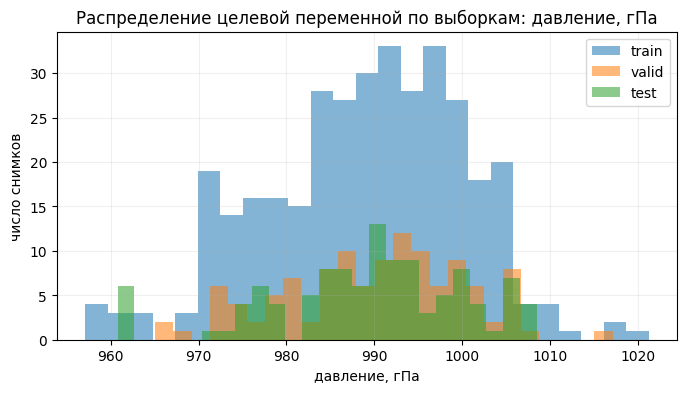

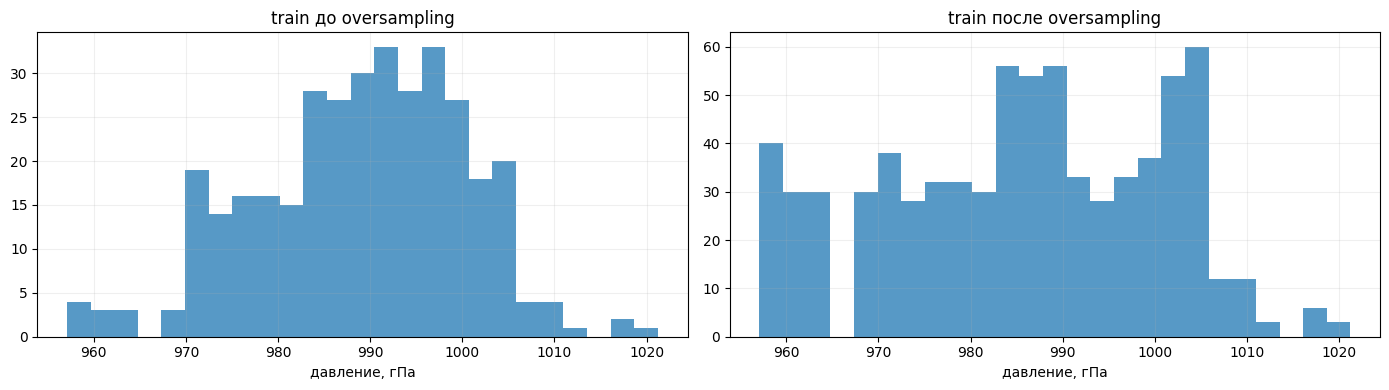

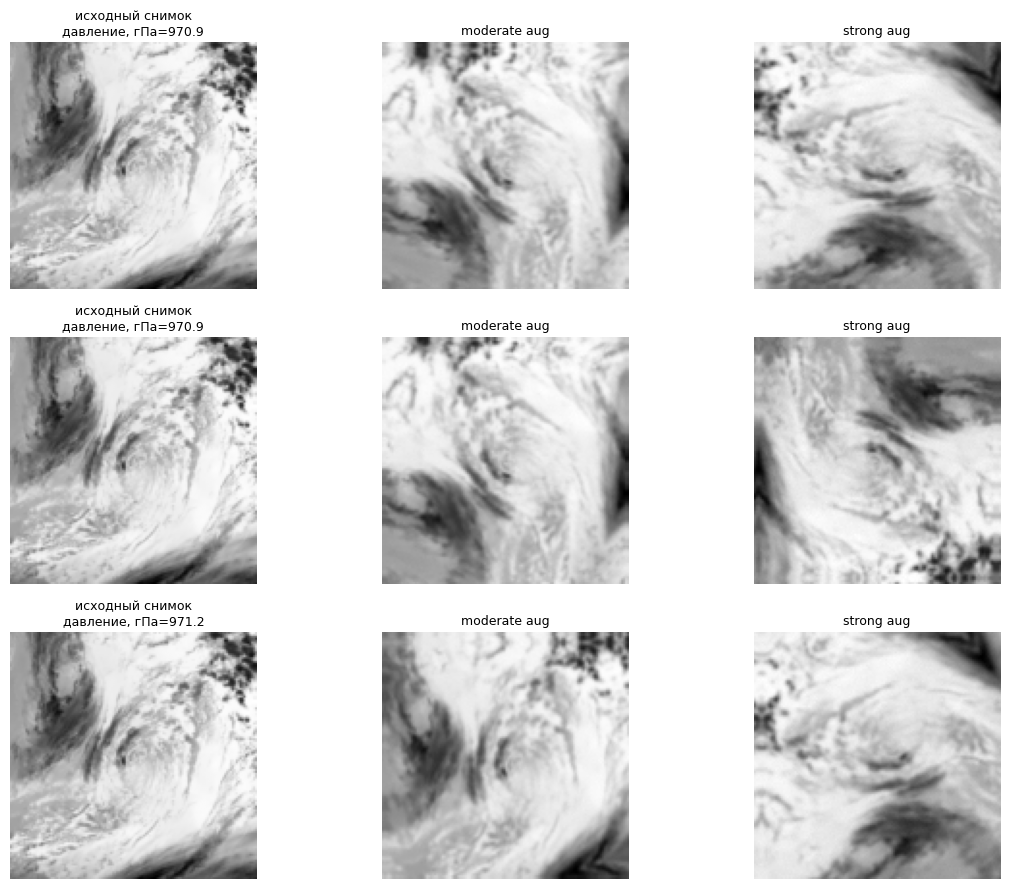

,параметр,значение
0,train mean,989.084106
1,train std,11.304483
2,valid baseline mae,8.392715
3,valid baseline rmse,10.281905
4,test baseline mae,8.550982
5,test baseline rmse,11.045683
6,train samples per epoch,2948
7,batch_size,16
8,epochs,250
9,learning_rate,0.0001


Epoch 1/250
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 45.1816 - mae: 11.2955 - rmse: 13.8950
   train_mae:   8.97 | val_mae:   8.16 | gap: -0.81 | best: 8.16 | pred_std val:  0.37 | учится, улучшение 3% от baseline
185/185 ━━━━━━━━━━━━━━━━━━━━ 99s 452ms/step - loss: 43.4264 - mae: 10.9290 - rmse: 13.4751 - val_loss: 29.8065 - val_mae: 8.1590 - val_rmse: 10.1330 - train_mae_target: 8.9726 - train_rmse_target: 11.2171 - val_mae_target: 8.1590 - val_rmse_target: 10.1330 - learning_rate: 1.0000e-04
Epoch 2/250
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 39.9592 - mae: 10.2208 - rmse: 12.5441
   train_mae:   8.25 | val_mae:   7.61 | gap: -0.64 | best: 7.61 | pred_std val:  3.03 | учится, улучшение 9% от baseline
185/185 ━━━━━━━━━━━━━━━━━━━━ 94s 461ms/step - loss: 39.8231 - mae: 10.2007 - rmse: 12.4915 - val_loss: 27.2036 - val_mae: 7.6086 - val_rmse: 9.5678 - train_mae_target: 8.2534 - train_rmse_target: 10.3930 - val_mae_target: 7.6086 - val_rmse_target: 9.5678 - learning_r

,параметр,linear calibration
0,a,0.613471
1,b,385.285828


,split,n,mae,rmse,pearson_r,true_min,true_mean,true_max,true_std,pred_min,pred_mean,pred_max,pred_std,bias_pred_minus_true
0,train raw,349,8.527518,10.661559,0.476182,957.075623,989.084106,1021.234375,11.304483,962.088745,985.766724,1004.545776,7.344872,-3.317407
1,valid raw,117,7.543852,10.486642,0.442321,965.039368,990.113770,1017.123108,10.230223,965.896851,985.911377,1001.979187,7.376130,-4.202319
2,test raw,112,10.130759,12.344034,0.247428,960.791199,989.419250,1008.483704,11.040598,968.363342,984.433777,1000.167603,6.349452,-4.985484
3,train calibrated,349,7.751873,10.023441,0.476182,957.075623,989.084106,1021.234375,11.304483,975.499268,990.025085,1001.545471,4.505865,0.940907
4,valid calibrated,117,7.035573,9.175046,0.442321,965.039368,990.113770,1017.123108,10.230223,977.835449,990.113770,999.970886,4.525040,0.000076
5,test calibrated,112,8.187183,10.762476,0.247428,960.791199,989.419250,1008.483704,11.040598,979.348572,989.207336,998.859558,3.895205,-0.211936
6,valid baseline mean,117,8.392715,10.281905,NaN,965.039368,990.113770,1017.123108,10.230223,989.084106,989.084106,989.084106,0.000000,-1.029607
7,test baseline mean,112,8.550982,11.045683,NaN,960.791199,989.419250,1008.483704,11.040598,989.084106,989.084045,989.084106,0.000061,-0.335122


,диагностика,значение
0,true test std,11.040598
1,raw pred test std,6.349452
2,cal pred test std,3.895205
3,train target std,11.304483
4,raw pred std / true std,0.575100
5,cal pred std / true std,0.352807


,bin,n,mae,rmse,bias_pred_minus_true,true_mean,pred_mean,true_std,pred_std,split,prediction_type
0,<970,3,19.711243,20.250115,19.711243,966.124573,985.835754,1.382504,3.261872,valid,raw
1,970–980,18,6.169355,8.485582,3.837474,975.349915,979.187378,2.988474,8.444405,valid,raw
2,980–990,32,3.935665,6.131966,-1.349586,985.600708,984.251099,2.890677,6.147721,valid,raw
3,990–1000,46,6.782713,9.938594,-6.569353,994.874207,988.304871,2.837167,6.857719,valid,raw
4,>=1000,18,15.250139,15.974362,-15.250139,1004.732849,989.482666,3.724181,3.960160,valid,raw
5,all,117,7.543852,10.486642,-4.202319,990.113770,985.911377,10.230223,7.376130,valid,raw
6,<970,3,23.942850,24.180292,23.942850,966.124573,990.067444,1.382504,2.001075,valid,calibrated
7,970–980,18,10.638909,11.613293,10.638909,975.349915,985.988831,2.988474,5.180398,valid,calibrated
8,980–990,32,4.637300,5.331931,3.494547,985.600708,989.095276,2.890677,3.771450,valid,calibrated
9,990–1000,46,4.081148,6.076083,-3.292146,994.874207,991.582275,2.837167,4.207008,valid,calibrated


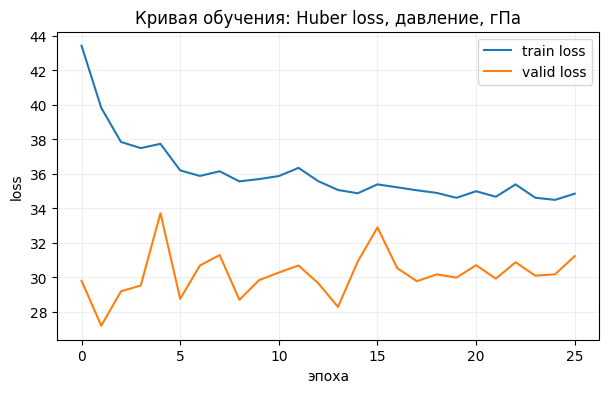

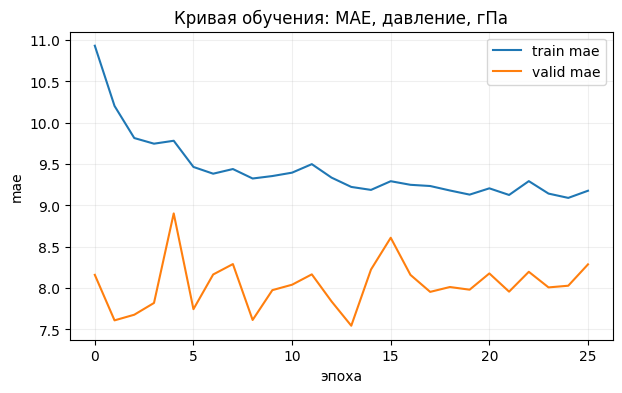

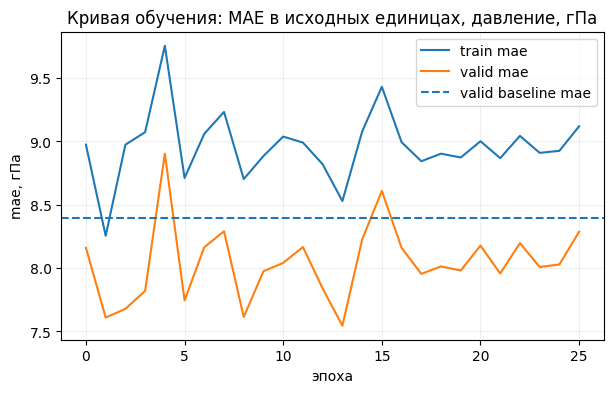

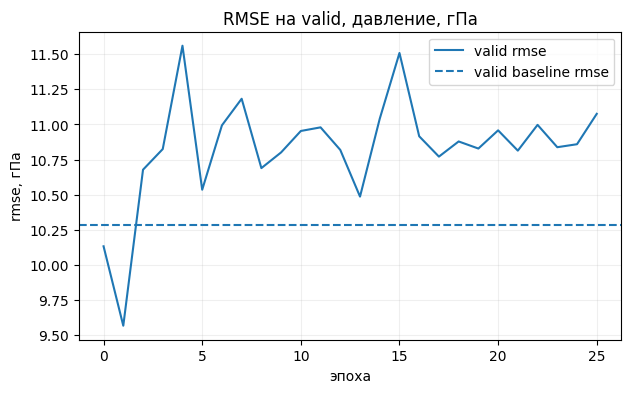

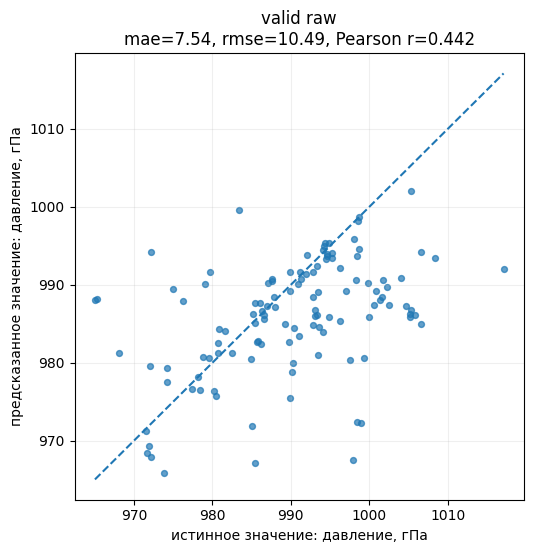

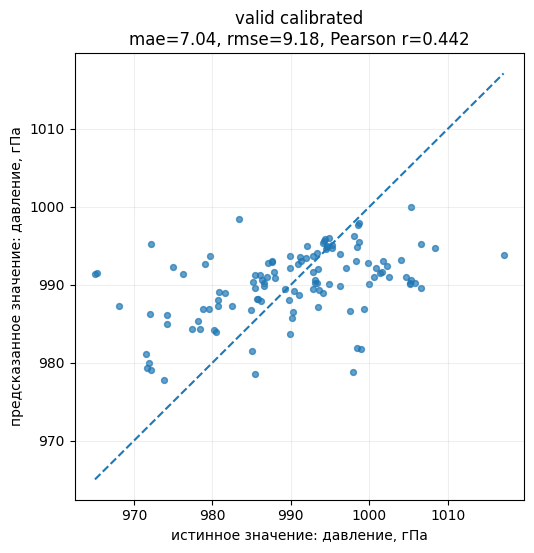

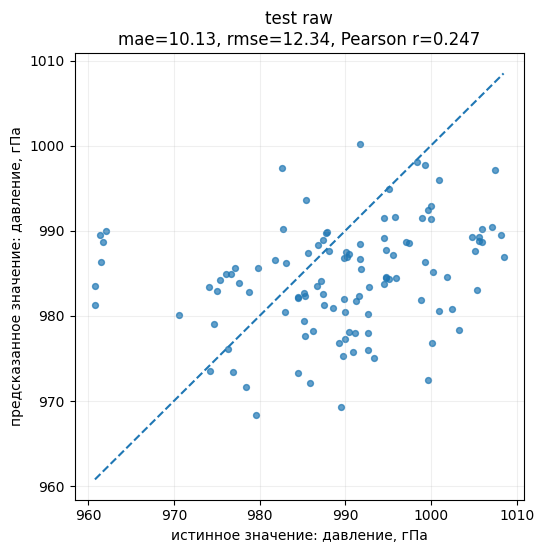

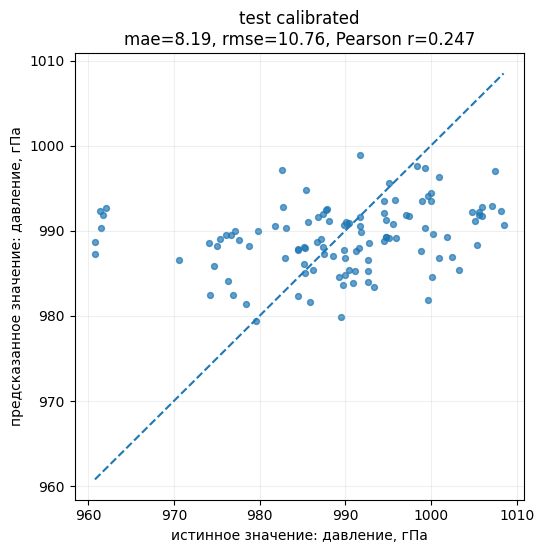

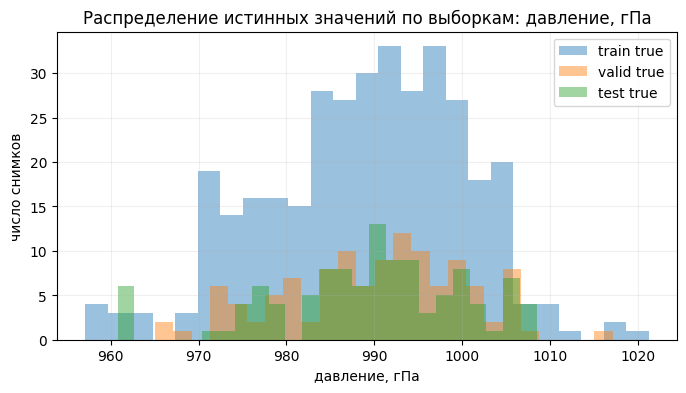

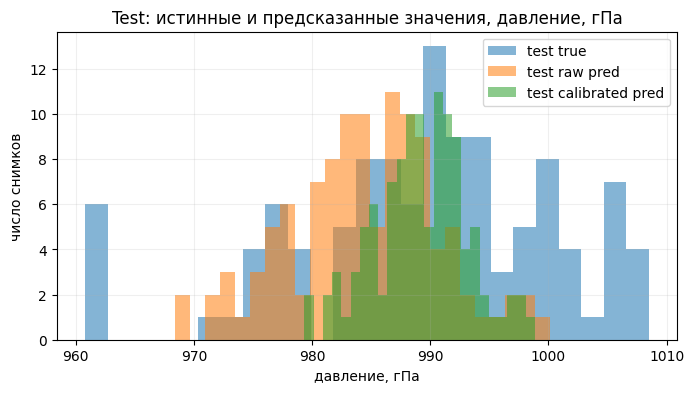

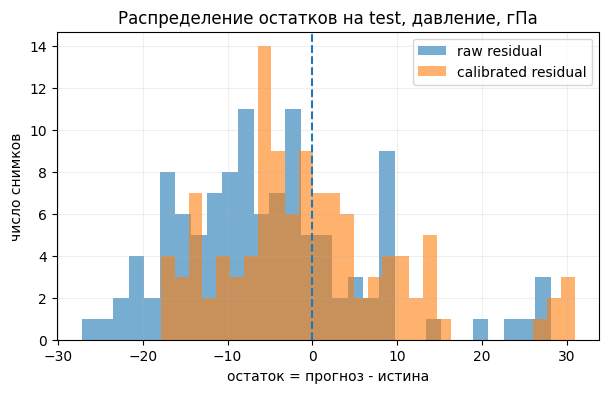

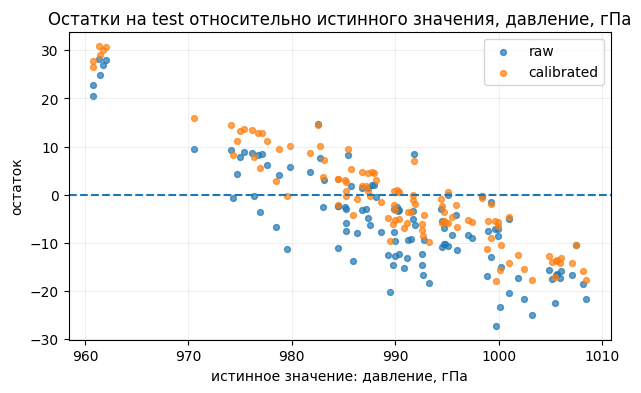

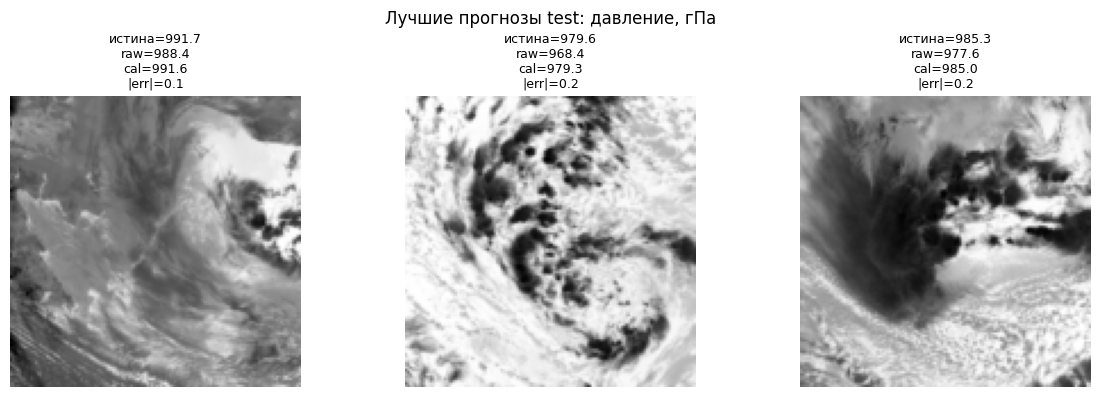

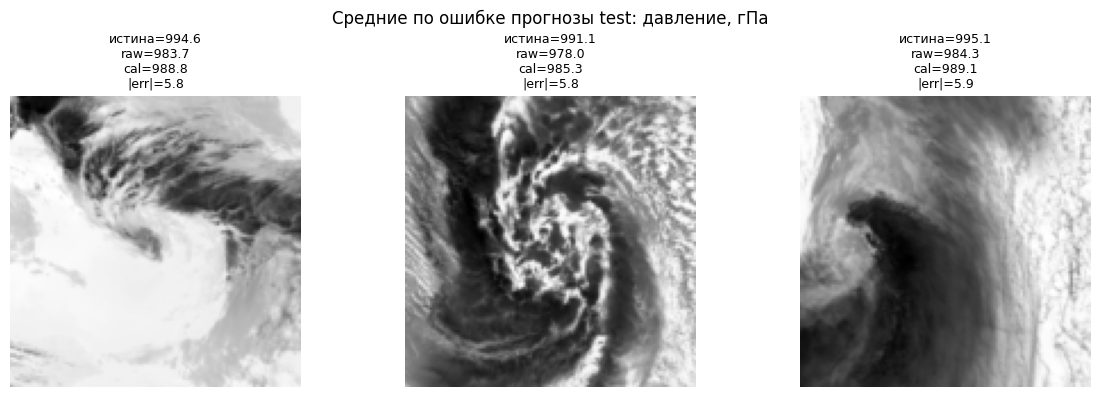

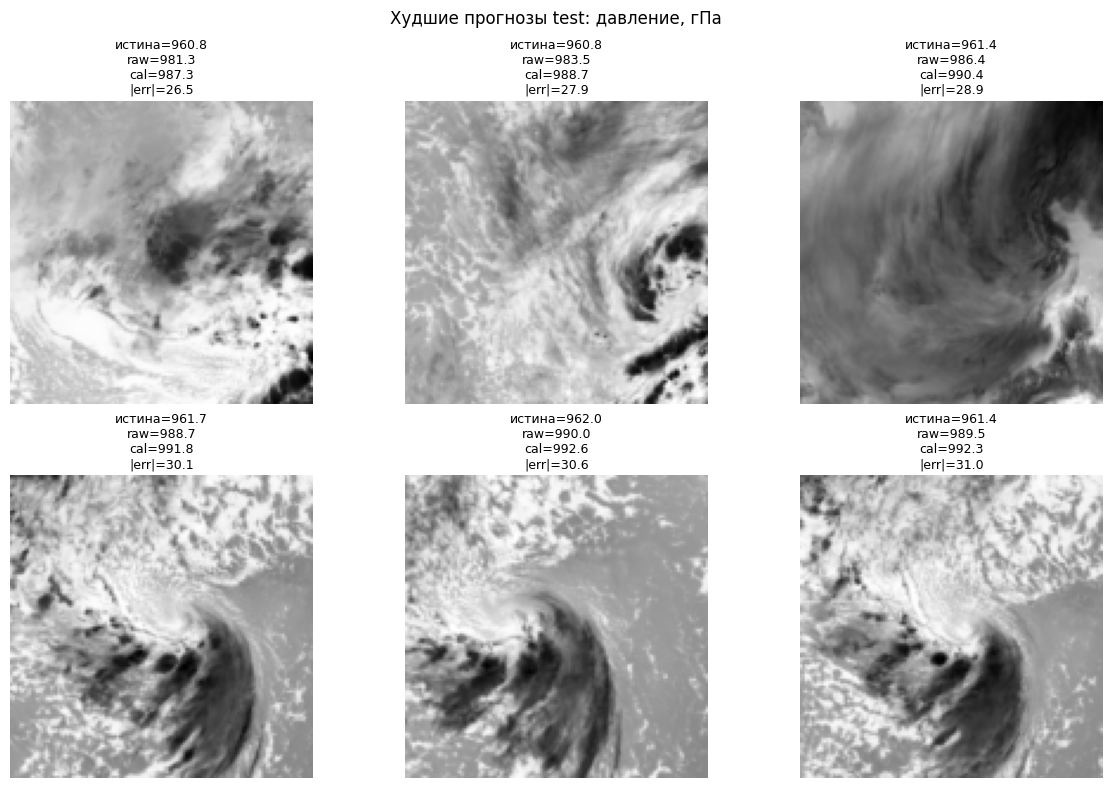

,ID,step,obs_datetime,lat,lon,true_slp,pred_slp_raw,pred_slp_calibrated,residual_raw_pred_minus_true,residual_calibrated_pred_minus_true,abs_error_raw,abs_error_calibrated,resolved_crop_path_npy,resolved_crop_path_npy
64,120200315550,12,2020-03-28 12:00:00,75.00,29.25,991.743103,988.412842,991.648376,-3.330261,-0.094727,3.330261,0.094727,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
102,220201206210,10,2020-12-16 05:00:00,53.25,167.75,979.561218,968.363342,979.348572,-11.197876,-0.212646,11.197876,0.212646,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
34,120200215060,13,2020-02-25 08:00:00,64.25,-29.50,985.261841,977.635803,985.036926,-7.626038,-0.224915,7.626038,0.224915,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...


,ID,step,obs_datetime,lat,lon,true_slp,pred_slp_raw,pred_slp_calibrated,residual_raw_pred_minus_true,residual_calibrated_pred_minus_true,abs_error_raw,abs_error_calibrated,resolved_crop_path_npy,resolved_crop_path_npy
61,120200315550,7,2020-03-28 07:00:00,75.25,21.00,994.565613,983.733215,988.777527,-10.832397,-5.788086,10.832397,5.788086,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
9,120200110530,14,2020-01-17 09:00:00,59.25,-56.00,991.118103,978.044861,985.287903,-13.073242,-5.830200,13.073242,5.830200,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
1,120200109640,22,2020-01-16 09:00:00,53.25,-27.25,995.065613,984.310852,989.131897,-10.754761,-5.933716,10.754761,5.933716,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...


,ID,step,obs_datetime,lat,lon,true_slp,pred_slp_raw,pred_slp_calibrated,residual_raw_pred_minus_true,residual_calibrated_pred_minus_true,abs_error_raw,abs_error_calibrated,resolved_crop_path_npy,resolved_crop_path_npy
25,120200213470,20,2020-02-22 08:00:00,71.50,-1.50,961.372498,989.536743,992.337830,28.164246,30.965332,28.164246,30.965332,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
27,120200213470,22,2020-02-22 10:00:00,70.75,-2.25,962.029358,990.018555,992.633423,27.989197,30.604065,27.989197,30.604065,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
26,120200213470,21,2020-02-22 09:00:00,71.25,-2.00,961.731873,988.660156,991.800049,26.928284,30.068176,26.928284,30.068176,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
22,120200213470,11,2020-02-21 23:00:00,73.75,4.00,961.438110,986.352051,990.384094,24.913940,28.945984,24.913940,28.945984,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
23,120200213470,12,2020-02-22 00:00:00,73.50,3.25,960.791199,983.536499,988.656860,22.745300,27.865662,22.745300,27.865662,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...
24,120200213470,13,2020-02-22 01:00:00,73.50,3.00,960.818115,981.337769,987.307983,20.519653,26.489868,20.519653,26.489868,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...,/content/drive/MyDrive/sentinel3/SLSTR/Solovie...


In [5]:
# ячейка 5
# модель восстановления давления

slp_results = run_one_target(
    X=X,
    metadata_ml=metadata_ml,
    target_col="slp",
    target_label="давление, гПа",
    target_units="гПа",
    target_bin_edges=np.array([-np.inf, 970, 980, 990, 1000, np.inf], dtype=float),
    target_bin_labels=["<970", "970–980", "980–990", "990–1000", ">=1000"],
)

,модель,статус,число параметров
0,Solovieva_PL_pressure_model_v3.keras,загружена,83193


,split,n,mae,rmse,pearson_r,true_min,true_mean,true_max,true_std,pred_min,pred_mean,pred_max,pred_std,bias_pred_minus_true
0,valid raw,117,7.187249,9.909813,0.450228,965.039370,990.113712,1017.123100,10.230225,965.006350,986.905240,1001.308200,6.719503,-3.208472
1,valid calibrated,117,6.985191,9.134710,0.450228,965.039370,990.113712,1017.123100,10.230225,975.103100,990.113842,999.986450,4.605930,0.000130
2,test raw,112,9.410798,11.716874,0.245656,960.791200,989.419230,1008.483700,11.040598,969.742250,985.890911,1000.487500,5.921118,-3.528318
3,test calibrated,112,8.215823,10.786654,0.245655,960.791200,989.419230,1008.483700,11.040598,978.349370,989.418561,999.423900,4.058673,-0.000669
4,valid baseline mean,117,8.392715,10.281905,NaN,965.039368,990.113770,1017.123108,10.230223,989.084106,989.084106,989.084106,0.000000,-1.029607
5,test baseline mean,112,8.550982,11.045683,NaN,960.791199,989.419250,1008.483704,11.040598,989.084106,989.084045,989.084106,0.000061,-0.335122


,bin,n,mae,rmse,bias_pred_minus_true,true_mean,pred_mean,true_std,pred_std,split,prediction_type
0,<970,3,20.391397,20.690462,20.391397,966.124573,986.515930,1.382504,2.126963,valid,raw
1,970–980,18,6.758039,9.436891,5.574758,975.349915,980.924683,2.988474,8.379172,valid,raw
2,980–990,32,3.733780,5.877402,-0.157528,985.600708,985.443176,2.890677,5.827724,valid,raw
3,990–1000,46,6.171458,8.840653,-6.024985,994.874207,988.849243,2.837167,5.766836,valid,raw
4,>=1000,18,14.151171,14.723384,-14.151171,1004.732849,990.581604,3.724181,3.793099,valid,raw
5,all,117,7.187248,9.909812,-3.208474,990.113770,986.905151,10.230223,6.719502,valid,raw
6,<970,3,23.722433,23.891445,23.722433,966.124573,989.846985,1.382504,1.457933,valid,calibrated
7,970–980,18,10.664514,11.880403,10.664514,975.349915,986.014343,2.988474,5.743561,valid,calibrated
8,980–990,32,4.850748,5.594102,3.510950,985.600708,989.111633,2.890677,3.994656,valid,calibrated
9,990–1000,46,3.937680,5.983567,-3.427886,994.874207,991.446472,2.837167,3.952923,valid,calibrated


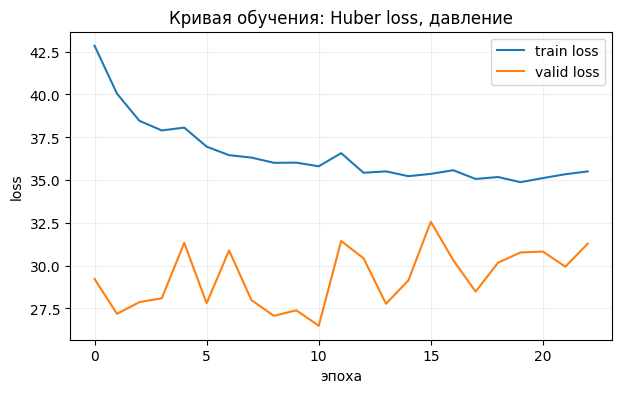

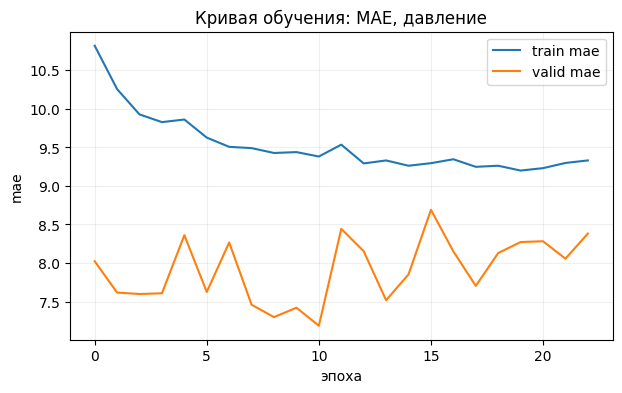

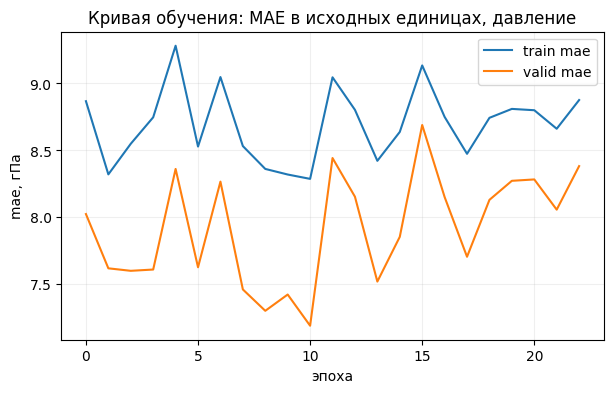

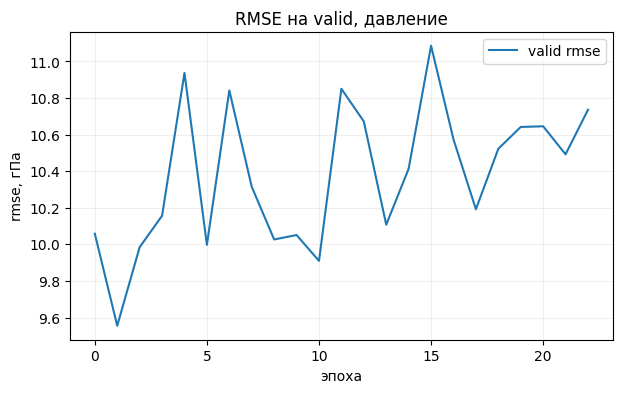

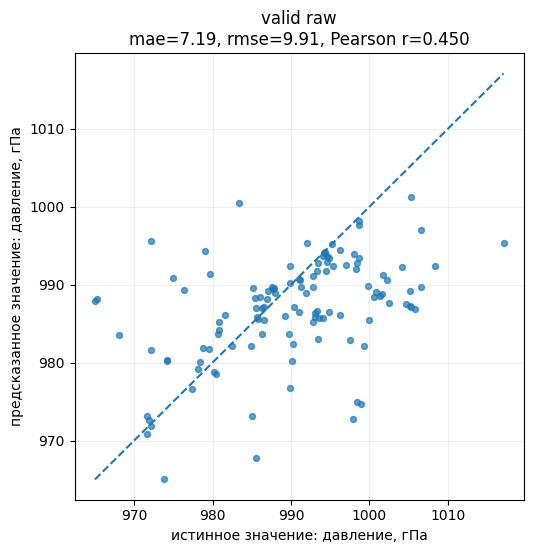

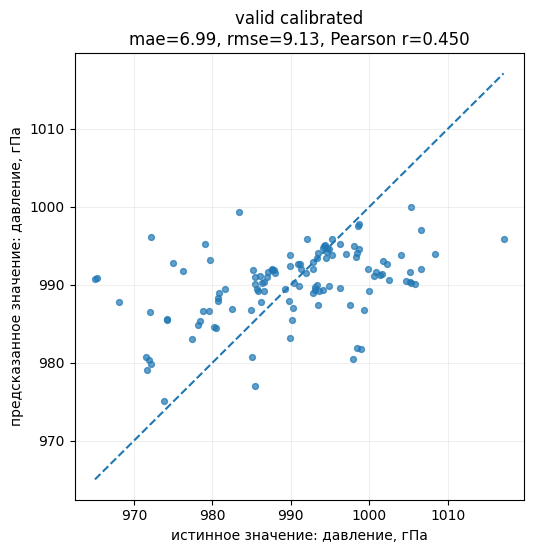

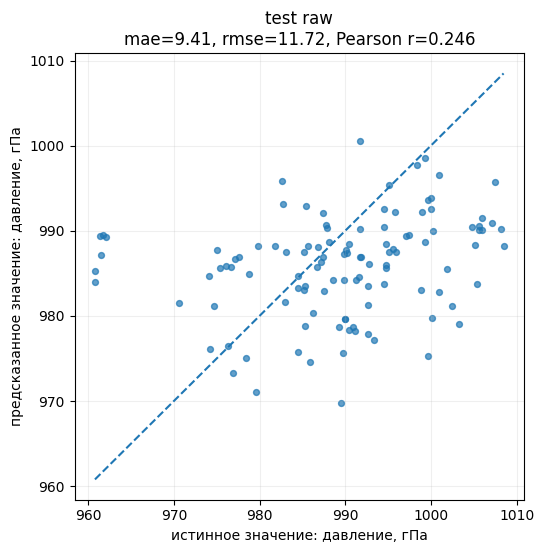

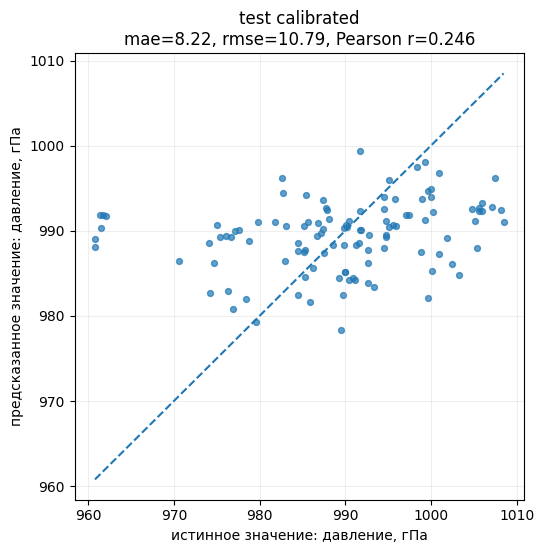

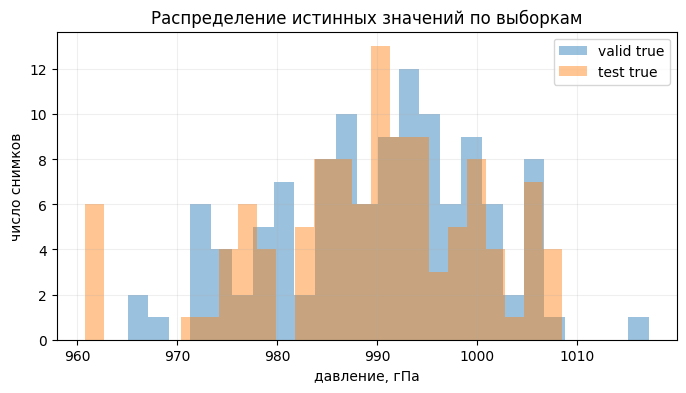

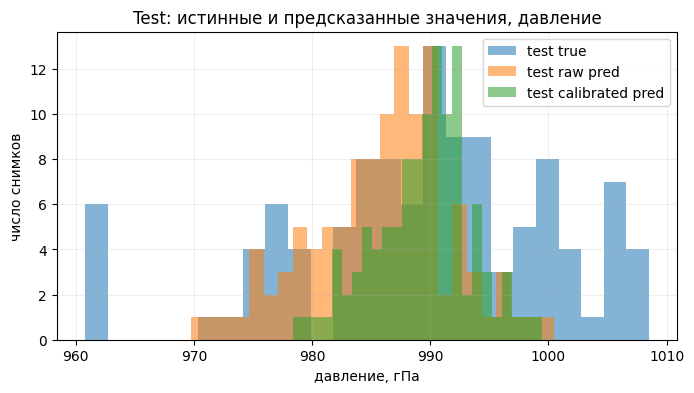

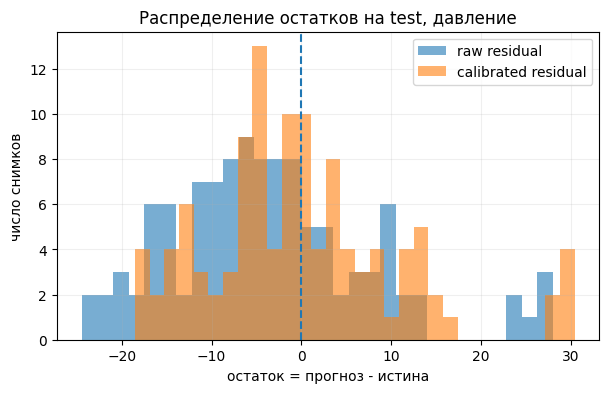

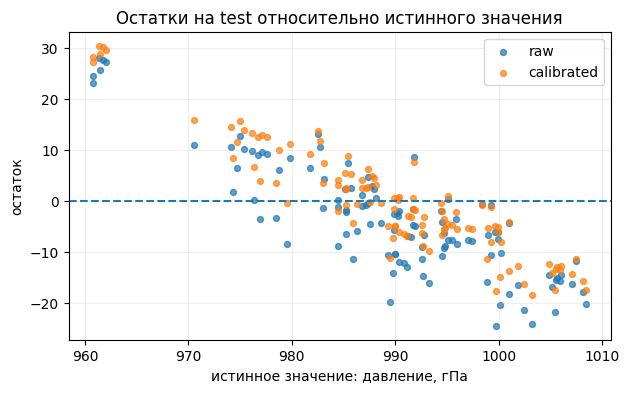

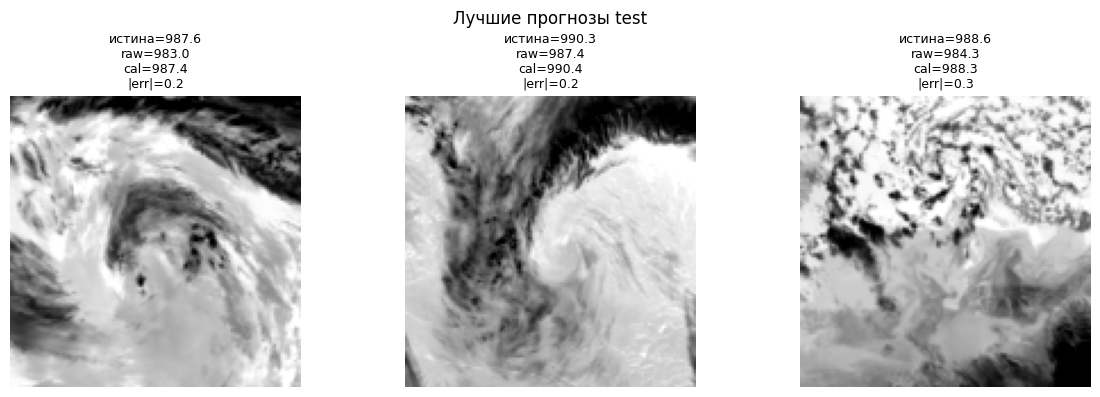

,ID,step,obs_datetime,lat,lon,true_slp,pred_slp_raw,pred_slp_calibrated,residual_raw_pred_minus_true,residual_calibrated_pred_minus_true,abs_error_raw,abs_error_calibrated
67,120200316070,7,2020-03-29 08:00:00,68.25,49.0,987.56370,982.96550,987.41330,-4.598206,-0.150391,4.598206,0.150391
70,120200409050,16,2020-04-19 17:00:00,72.75,-65.5,990.26495,987.36370,990.42810,-2.901245,0.163147,2.901245,0.163147
8,120200110110,23,2020-01-17 06:00:00,66.75,-30.5,988.61060,984.26117,988.30145,-4.349426,-0.309143,4.349426,0.309143


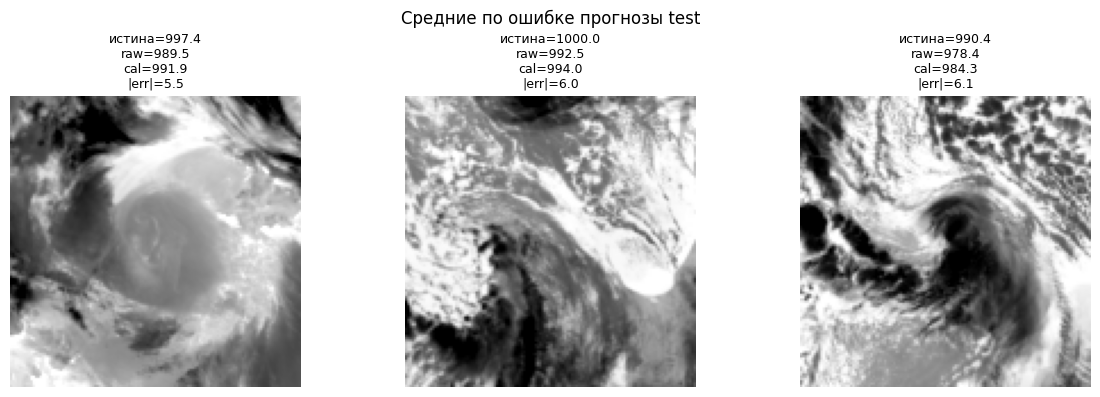

,ID,step,obs_datetime,lat,lon,true_slp,pred_slp_raw,pred_slp_calibrated,residual_raw_pred_minus_true,residual_calibrated_pred_minus_true,abs_error_raw,abs_error_calibrated
54,120200314430,8,2020-03-26 20:00:00,73.75,24.75,997.4262,989.5019,991.89374,-7.924316,-5.532471,7.924316,5.532471
100,220201103360,12,2020-11-09 00:00:00,55.50,143.75,999.9806,992.5494,993.98267,-7.431213,-5.997925,7.431213,5.997925
32,120200214390,23,2020-02-24 07:00:00,63.75,-33.75,990.4100,978.3822,984.27167,-12.027771,-6.138306,12.027771,6.138306


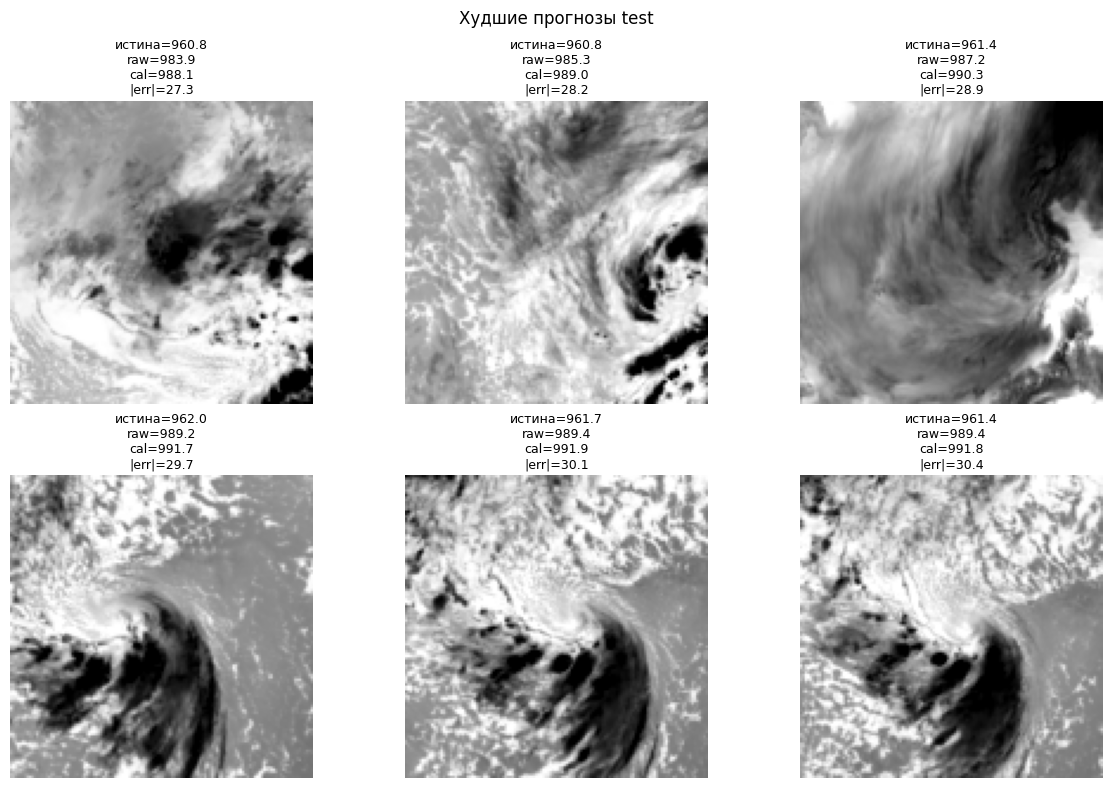

,ID,step,obs_datetime,lat,lon,true_slp,pred_slp_raw,pred_slp_calibrated,residual_raw_pred_minus_true,residual_calibrated_pred_minus_true,abs_error_raw,abs_error_calibrated
24,120200213470,13,2020-02-22 01:00:00,73.50,3.00,960.81810,983.94293,988.08330,23.124817,27.265198,23.124817,27.265198
23,120200213470,12,2020-02-22 00:00:00,73.50,3.25,960.79120,985.28326,989.00210,24.492065,28.210876,24.492065,28.210876
22,120200213470,11,2020-02-21 23:00:00,73.75,4.00,961.43810,987.20320,990.31805,25.765076,28.879944,25.765076,28.879944
27,120200213470,22,2020-02-22 10:00:00,70.75,-2.25,962.02936,989.22770,991.70580,27.198364,29.676453,27.198364,29.676453
26,120200213470,21,2020-02-22 09:00:00,71.25,-2.00,961.73190,989.44750,991.85645,27.715637,30.124573,27.715637,30.124573
25,120200213470,20,2020-02-22 08:00:00,71.50,-1.50,961.37250,989.39530,991.82070,28.022827,30.448181,28.022827,30.448181


In [7]:
# ячейка 5a
# загрузка Solovieva_PL_pressure_model_v3,
# отображение метрик качества и графиков

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display

# 1. загрузка модели из проектной папки

base_dir = Path("/content/drive/MyDrive/sentinel3/SLSTR")
project_dir = base_dir / "Solovieva_diploma_project"

model_dir = project_dir / "Solovieva_PL_regression_model_v3"
model_path = model_dir / "Solovieva_PL_pressure_model_v3.keras"

if not model_path.exists():
    raise FileNotFoundError("модель Solovieva_PL_pressure_model_v3.keras не найдена")

solovieva_pressure_model_v3 = tf.keras.models.load_model(model_path, compile=False)

display(
    pd.DataFrame(
        {
            "модель": ["Solovieva_PL_pressure_model_v3.keras"],
            "статус": ["загружена"],
            "число параметров": [solovieva_pressure_model_v3.count_params()],
        }
    )
)

# 2. чтение сохраненных результатов этой модели

results_dir = (
    base_dir
    / "ml_pressure_model_010526"
    / "FINAL_DIPLOMA"
    / "pressure_model"
)

timestamp = "20260508_1853"

metrics_path = results_dir / f"metrics_{timestamp}.csv"
bin_metrics_path = results_dir / f"bin_metrics_{timestamp}.csv"
pred_valid_path = results_dir / f"pred_valid_{timestamp}.csv"
pred_test_path = results_dir / f"pred_test_{timestamp}.csv"
history_path = results_dir / f"history_{timestamp}.csv"
config_path = results_dir / f"config_{timestamp}.json"

if not metrics_path.exists():
    raise FileNotFoundError("таблица metrics для модели v3 не найдена")

metrics_saved = pd.read_csv(metrics_path)

bin_metrics_saved = (
    pd.read_csv(bin_metrics_path)
    if bin_metrics_path.exists()
    else pd.DataFrame()
)

pred_valid_df = (
    pd.read_csv(pred_valid_path)
    if pred_valid_path.exists()
    else pd.DataFrame()
)

pred_test_df = (
    pd.read_csv(pred_test_path)
    if pred_test_path.exists()
    else pd.DataFrame()
)

history_df = (
    pd.read_csv(history_path)
    if history_path.exists()
    else pd.DataFrame()
)

if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        model_config = json.load(f)
else:
    model_config = {}

# 3. пересчет метрик с pearson_r

def find_prediction_columns(df):
    true_cols = [c for c in df.columns if c.startswith("true_")]
    raw_cols = [c for c in df.columns if c.startswith("pred_") and c.endswith("_raw")]
    cal_cols = [c for c in df.columns if c.startswith("pred_") and c.endswith("_calibrated")]

    true_col = true_cols[0] if len(true_cols) > 0 else None
    raw_col = raw_cols[0] if len(raw_cols) > 0 else None
    cal_col = cal_cols[0] if len(cal_cols) > 0 else None

    return true_col, raw_col, cal_col


def calc_pearson(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if len(y_true) < 2:
        return np.nan

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    return float(np.corrcoef(y_true, y_pred)[0, 1])


def make_metrics_row(y_true, y_pred, split_name):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    return {
        "split": split_name,
        "n": int(len(y_true)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "pearson_r": calc_pearson(y_true, y_pred),
        "true_min": float(y_true.min()),
        "true_mean": float(y_true.mean()),
        "true_max": float(y_true.max()),
        "true_std": float(y_true.std()),
        "pred_min": float(y_pred.min()),
        "pred_mean": float(y_pred.mean()),
        "pred_max": float(y_pred.max()),
        "pred_std": float(y_pred.std()),
        "bias_pred_minus_true": float(np.mean(y_pred - y_true)),
    }


metric_rows = []

if len(pred_valid_df) > 0:
    true_col_valid, raw_col_valid, cal_col_valid = find_prediction_columns(pred_valid_df)

    y_valid_true = pred_valid_df[true_col_valid].values
    y_valid_raw = pred_valid_df[raw_col_valid].values
    y_valid_cal = pred_valid_df[cal_col_valid].values

    metric_rows.append(make_metrics_row(y_valid_true, y_valid_raw, "valid raw"))
    metric_rows.append(make_metrics_row(y_valid_true, y_valid_cal, "valid calibrated"))

if len(pred_test_df) > 0:
    true_col_test, raw_col_test, cal_col_test = find_prediction_columns(pred_test_df)

    y_test_true = pred_test_df[true_col_test].values
    y_test_raw = pred_test_df[raw_col_test].values
    y_test_cal = pred_test_df[cal_col_test].values

    metric_rows.append(make_metrics_row(y_test_true, y_test_raw, "test raw"))
    metric_rows.append(make_metrics_row(y_test_true, y_test_cal, "test calibrated"))

metrics_df = pd.DataFrame(metric_rows)

baseline_rows = metrics_saved[
    metrics_saved["split"].astype(str).str.contains("baseline", case=False, na=False)
].copy()

baseline_rows = baseline_rows.drop(
    columns=[c for c in baseline_rows.columns if c.lower() == "r2"],
    errors="ignore",
)

if len(baseline_rows) > 0:
    if "pearson_r" not in baseline_rows.columns:
        baseline_rows["pearson_r"] = np.nan

    for col in metrics_df.columns:
        if col not in baseline_rows.columns:
            baseline_rows[col] = np.nan

    baseline_rows = baseline_rows[metrics_df.columns]
    metrics_df = pd.concat([metrics_df, baseline_rows], ignore_index=True)

metrics_df = metrics_df.drop(
    columns=[c for c in metrics_df.columns if c.lower() == "r2"],
    errors="ignore",
)

display(metrics_df)


if len(bin_metrics_saved) > 0:
    bin_metrics_df = bin_metrics_saved.drop(
        columns=[c for c in bin_metrics_saved.columns if c.lower() == "r2"],
        errors="ignore",
    )

    display(bin_metrics_df)
else:
    bin_metrics_df = pd.DataFrame()

# 4. графики обучения

if len(history_df) > 0:
    if "loss" in history_df.columns and "val_loss" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["loss"], label="train loss")
        plt.plot(history_df["val_loss"], label="valid loss")
        plt.xlabel("эпоха")
        plt.ylabel("loss")
        plt.title("Кривая обучения: Huber loss, давление")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

    if "mae" in history_df.columns and "val_mae" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["mae"], label="train mae")
        plt.plot(history_df["val_mae"], label="valid mae")
        plt.xlabel("эпоха")
        plt.ylabel("mae")
        plt.title("Кривая обучения: MAE, давление")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

    if "train_mae_target" in history_df.columns and "val_mae_target" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["train_mae_target"], label="train mae")
        plt.plot(history_df["val_mae_target"], label="valid mae")
        plt.xlabel("эпоха")
        plt.ylabel("mae, гПа")
        plt.title("Кривая обучения: MAE в исходных единицах, давление")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

    if "val_rmse_target" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["val_rmse_target"], label="valid rmse")
        plt.xlabel("эпоха")
        plt.ylabel("rmse, гПа")
        plt.title("RMSE на valid, давление")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

# 5. scatter-графики true-pred

def plot_true_pred(y_true, y_pred, title):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(math.sqrt(mean_squared_error(y_true, y_pred)))
    pearson_r = calc_pearson(y_true, y_pred)

    line_min = min(float(y_true.min()), float(y_pred.min()))
    line_max = max(float(y_true.max()), float(y_pred.max()))

    plt.figure(figsize=(5.8, 5.8))
    plt.scatter(y_true, y_pred, s=18, alpha=0.7)
    plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
    plt.xlabel("истинное значение: давление, гПа")
    plt.ylabel("предсказанное значение: давление, гПа")
    plt.title(f"{title}\nmae={mae:.2f}, rmse={rmse:.2f}, Pearson r={pearson_r:.3f}")
    plt.grid(alpha=0.2)
    plt.show()


if len(pred_valid_df) > 0:
    plot_true_pred(y_valid_true, y_valid_raw, "valid raw")
    plot_true_pred(y_valid_true, y_valid_cal, "valid calibrated")

if len(pred_test_df) > 0:
    plot_true_pred(y_test_true, y_test_raw, "test raw")
    plot_true_pred(y_test_true, y_test_cal, "test calibrated")

# 6. распределения и остатки

if len(pred_valid_df) > 0 and len(pred_test_df) > 0:
    plt.figure(figsize=(8, 4))
    plt.hist(y_valid_true, bins=25, alpha=0.45, label="valid true")
    plt.hist(y_test_true, bins=25, alpha=0.45, label="test true")
    plt.xlabel("давление, гПа")
    plt.ylabel("число снимков")
    plt.title("Распределение истинных значений по выборкам")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

if len(pred_test_df) > 0:
    plt.figure(figsize=(8, 4))
    plt.hist(y_test_true, bins=25, alpha=0.55, label="test true")
    plt.hist(y_test_raw, bins=25, alpha=0.55, label="test raw pred")
    plt.hist(y_test_cal, bins=25, alpha=0.55, label="test calibrated pred")
    plt.xlabel("давление, гПа")
    plt.ylabel("число снимков")
    plt.title("Test: истинные и предсказанные значения, давление")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    test_raw_residuals = y_test_raw - y_test_true
    test_cal_residuals = y_test_cal - y_test_true

    plt.figure(figsize=(7, 4))
    plt.hist(test_raw_residuals, bins=30, alpha=0.6, label="raw residual")
    plt.hist(test_cal_residuals, bins=30, alpha=0.6, label="calibrated residual")
    plt.axvline(0, linestyle="--")
    plt.xlabel("остаток = прогноз - истина")
    plt.ylabel("число снимков")
    plt.title("Распределение остатков на test, давление")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.scatter(y_test_true, test_raw_residuals, s=18, alpha=0.7, label="raw")
    plt.scatter(y_test_true, test_cal_residuals, s=18, alpha=0.7, label="calibrated")
    plt.axhline(0, linestyle="--")
    plt.xlabel("истинное значение: давление, гПа")
    plt.ylabel("остаток")
    plt.title("Остатки на test относительно истинного значения")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# 7. снимки лучших, средних и худших прогнозов

def load_crop_for_plot(row):
    path_value = None

    for col in ["resolved_crop_path_npy", "npy_path", "npy_relative_path"]:
        if col in row.index and pd.notna(row[col]):
            path_value = row[col]
            break

    if path_value is None:
        return None

    p = Path(str(path_value))

    if not p.exists():
        p2 = project_dir / str(path_value)
        if p2.exists():
            p = p2

    if not p.exists():
        return None

    if "prepare_crop_array" in globals():
        img, _ = prepare_crop_array(p, img_size=img_size)
        return img.squeeze()

    arr = np.load(p, allow_pickle=False).astype(np.float32)
    arr = np.squeeze(arr)

    return arr


def show_prediction_examples(pred_df):
    if len(pred_df) == 0:
        return

    true_col, raw_col, cal_col = find_prediction_columns(pred_df)

    if true_col is None or raw_col is None or cal_col is None:
        return

    df = pred_df.copy()
    df["_abs_error"] = np.abs(df[cal_col].values - df[true_col].values)

    order = np.argsort(df["_abs_error"].values)

    best_idx = order[:min(3, len(order))]
    mid_center = len(order) // 2
    mid_idx = order[max(0, mid_center - 1):min(len(order), mid_center + 2)]
    worst_idx = order[-min(6, len(order)):]

    groups = [
        ("Лучшие прогнозы test", best_idx),
        ("Средние по ошибке прогнозы test", mid_idx),
        ("Худшие прогнозы test", worst_idx),
    ]

    for group_title, idx_list in groups:
        n = len(idx_list)

        if n == 0:
            continue

        n_cols = min(3, n)
        n_rows = int(np.ceil(n / n_cols))

        plt.figure(figsize=(4 * n_cols, 4 * n_rows))

        for j, idx in enumerate(idx_list):
            row = df.iloc[int(idx)]
            img = load_crop_for_plot(row)

            plt.subplot(n_rows, n_cols, j + 1)

            if img is not None:
                vmin = np.nanpercentile(img, 2)
                vmax = np.nanpercentile(img, 98)
                plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)

            plt.title(
                f"истина={row[true_col]:.1f}\n"
                f"raw={row[raw_col]:.1f}\n"
                f"cal={row[cal_col]:.1f}\n"
                f"|err|={row['_abs_error']:.1f}",
                fontsize=9,
            )

            plt.axis("off")

        plt.suptitle(group_title)
        plt.tight_layout()
        plt.show()

        table_cols = [
            "ID",
            "step",
            "obs_datetime",
            "lat",
            "lon",
            true_col,
            raw_col,
            cal_col,
            "residual_raw_pred_minus_true",
            "residual_calibrated_pred_minus_true",
            "abs_error_raw",
            "abs_error_calibrated",
        ]

        table_cols = [c for c in table_cols if c in df.columns]
        display(df.iloc[idx_list][table_cols].sort_values("abs_error_calibrated"))


if len(pred_test_df) > 0:
    show_prediction_examples(pred_test_df)

# 8. объект результата

solovieva_pressure_model_v3_results = {
    "target_col": model_config.get("target_col", "slp"),
    "target_label": model_config.get("target_label", "давление, гПа"),
    "model": solovieva_pressure_model_v3,
    "history_df": history_df,
    "metrics_df": metrics_df,
    "bin_metrics": bin_metrics_df,
    "pred_valid_df": pred_valid_df,
    "pred_test_df": pred_test_df,
    "config": model_config,
}

### Анализ качества модели восстановления центрального давления

В ячейке загружена итоговая модель `Solovieva_PL_pressure_model_v3.keras`. Модель содержит 83 193 параметра. Это компактная сверточная регрессионная модель, предназначенная для восстановления центрального давления ПЦ по спутниковым фрагментам Sentinel-3 SLSTR. На выходе модель выдает одно непрерывное значение — оценку давления в гПа.

В анализе используются два варианта прогноза:

- `raw` — исходный прогноз модели;
- `calibrated` — прогноз после калибровки, приведенный к среднему уровню целевой переменной.

Качество оценивается по MAE, RMSE и коэффициенту корреляции Pearson r. MAE показывает среднюю абсолютную ошибку в гПа. RMSE сильнее реагирует на крупные ошибки. Pearson r показывает, насколько предсказания связаны с изменчивостью истинных значений давления.

### Архитектура модели восстановления центрального давления

Размер модели выбран как компромисс между способностью извлекать пространственные признаки из спутникового изображения и риском переобучения на сравнительно небольшой выборке ПЦ.

Модель принимает два типа входных данных:

1. спутниковый фрагмент Sentinel-3 SLSTR размером 128 × 128 пикселей с одним каналом;
2. контекстные признаки, описывающие положение и сезон наблюдения.

Модель имеет два входа. Первый вход содержит спутниковый фрагмент Sentinel-3 SLSTR размером 128 × 128 пикселей с одним каналом. По этому изображению сверточная часть модели извлекает скрытые пространственные признаки распределения яркостной температуры. Эти признаки могут быть связаны с контрастом облачного поля, общей формой облачной структуры, степенью организованности вихря, положением холодных облачных областей и пространственным рисунком сцены.

Второй вход содержит пять контекстных признаков: нормированную широту, синус и косинус долготы, синус и косинус месяца. Широта нормируется по формуле `(lat - 70) / 15`. Долгота и месяц кодируются через синус и косинус, поскольку это циклические величины: близкие значения на границе шкалы должны оставаться близкими и для модели. Такая кодировка позволяет учитывать региональный и сезонный контекст наблюдения без разрыва на границе 0/360° для долготы и на границе декабрь/январь для месяца.

После обработки изображения и контекстных признаков две ветки объединяются через слой `Concatenate`. Далее объединенный вектор поступает в полносвязные слои, которые формируют итоговый регрессионный прогноз.

Перед подачей в модель изображения нормализуются по среднему и стандартному отклонению, рассчитанным на обучающей выборке. Это приводит значения пикселей к сопоставимому масштабу и облегчает обучение нейросети. Целевая переменная для давления используется напрямую в гПа. Логарифмическое преобразование в этой версии применяется только для завихренности, поскольку у нее более выраженный правый хвост распределения.

### Сверточный блок изображения

Основная часть модели состоит из четырех последовательных сверточных блоков. Они постепенно переводят исходное изображение в более компактное описание его пространственной структуры.

Первый блок использует 16 фильтров размером 3 × 3. Он выделяет простые локальные элементы изображения: границы облачности, небольшие контрасты яркостной температуры и мелкие текстурные различия. После свертки применяется Batch Normalization, затем ReLU-активация и MaxPooling2D.

Batch Normalization стабилизирует распределение признаков внутри сети и делает обучение менее чувствительным к масштабу входных значений. ReLU добавляет нелинейность, без которой сеть сводилась бы к набору линейных преобразований. MaxPooling уменьшает пространственный размер карт признаков и оставляет наиболее выраженные локальные отклики. За счет этого модель постепенно переходит от анализа отдельных пикселей к анализу более крупных фрагментов облачного поля.

Второй сверточный блок содержит 32 фильтра. На этом уровне модель может выделять более сложные локальные структуры: дугообразные облачные зоны, участки спиральной организации, резкие переходы между холодными и теплыми областями. После этого блока добавлен Dropout 0.20. Он случайно отключает часть признаков во время обучения и снижает риск того, что модель запомнит отдельные сцены вместо обобщения закономерностей.

Третий блок использует 64 фильтра. Он отвечает за извлечение еще более сложных пространственных признаков. Здесь модель уже работает не с отдельными границами, а с более крупными элементами морфологии ПЦ: участками закрученной облачности, центральной зоной вихря и общей асимметрией облачного поля. После блока используется Dropout 0.25, поскольку на этом уровне число признаков увеличивается, а риск переобучения возрастает.

Четвертый блок содержит 96 фильтров. Это самый глубокий сверточный уровень модели. Он формирует итоговое пространственное представление спутникового фрагмента. На этом этапе модель должна собрать информацию о всей сцене: насколько организована облачность, выражена ли вихревая структура, есть ли контраст между центральной частью циклона и окружением, насколько сцена похожа на случаи с более низким или более высоким давлением в обучающей выборке.

После четвертого сверточного блока используется GlobalAveragePooling2D. Этот слой усредняет каждую карту признаков по пространству и превращает набор карт в компактный вектор признаков. Такой подход сильно уменьшает число параметров по сравнению с использованием Flatten. Это важно для данной задачи, поскольку выборка ограничена, а слишком большая полносвязная часть быстро привела бы к переобучению. После GlobalAveragePooling2D добавлен Dropout 0.35 как дополнительная регуляризация перед объединением с контекстными признаками.

### Блок контекстных признаков

Контекстные признаки проходят через отдельный полносвязный слой на 16 нейронов с ReLU-активацией. Этот небольшой блок нужен для того, чтобы привести широту, долготу и месяц к внутреннему представлению, совместимому с признаками изображения.

После этого применяется Dropout 0.10. Он слабее, чем в сверточной ветке, поскольку контекстных признаков мало и они уже имеют компактную форму. Слишком сильное отключение таких признаков могло бы ухудшить использование сезонной и региональной информации.

Затем признаки изображения и контекстные признаки объединяются через слой Concatenate. После объединения модель получает единый вектор, в котором одновременно представлены спутниковая морфология ПЦ и сведения о географическом и сезонном контексте наблюдения.

### Регрессионная часть модели

После объединения признаков используется полносвязный блок:

- Dense 64 с ReLU;
- Dropout 0.20;
- Dense 32 с ReLU;
- выходной Dense 1.

Полносвязные слои преобразуют извлеченные признаки в итоговую оценку давления. Первый слой на 64 нейрона позволяет модели учесть взаимодействия между изображением и контекстом. Например, похожая облачная структура может иметь разную связь с давлением в разных регионах или в разные месяцы. Dropout 0.20 снижает риск переобучения на отдельных сочетаниях признаков. Второй слой на 32 нейрона дополнительно сжимает представление перед выходом.

Выходной слой содержит один нейрон без функции активации. Это соответствует регрессионной постановке задачи: модель должна предсказать одно непрерывное значение давления в гПа. Смещение выходного слоя инициализируется средним значением целевой переменной на обучающей выборке. Это помогает модели в начале обучения стартовать с разумного уровня давления, близкого к простому прогнозу среднего значения целевой переменной.

### Функция потерь и стратегия обучения

Для обучения используется функция потерь Huber loss. Она сочетает свойства MAE и MSE: для небольших ошибок ведет себя близко к квадратичной ошибке, а для крупных ошибок становится менее чувствительной к выбросам. Это важно для давления ПЦ, поскольку в выборке есть редкие экстремальные случаи, например глубокие циклоны с давлением ниже 970 гПа. Обычная MSE могла бы слишком сильно подстраивать модель под такие ошибки, а MAE давала бы менее гладкий сигнал для оптимизации.

Оптимизация выполняется алгоритмом Adam. В качестве метрик во время обучения дополнительно рассчитываются MAE и RMSE. MAE удобна для интерпретации, поскольку показывает среднюю ошибку в гПа. RMSE сильнее реагирует на крупные промахи и помогает увидеть, насколько модель ошибается на сложных случаях.

Для контроля обучения используются два callback-механизма. EarlyStopping останавливает обучение, если качество на проверочной выборке перестает улучшаться, и возвращает лучшие веса модели. ReduceLROnPlateau уменьшает скорость обучения, если ошибка на valid перестает снижаться. Это позволяет модели аккуратнее дообучаться после выхода на плато.

### Аугментация данных

Во время обучения используется онлайн-аугментация изображений. Она включает отражения, повороты, небольшие сдвиги, масштабирование и добавление шума. Для обычных примеров применяется умеренная аугментация, а для редких диапазонов давления — более сильная. Это нужно для того, чтобы модель видела больше вариантов облачной структуры и меньше зависела от конкретного положения вихря в кадре.

Аугментация не меняет физический смысл примера, поворот спутникового фрагмента сохраняет общую морфологию циклона. При этом модель становится менее чувствительной к ориентации вихря на снимке и к небольшим смещениям центра.

### Общая логика архитектуры

Архитектура построена так, чтобы сначала извлечь признаки из изображения, затем дополнить их контекстом наблюдения, а после этого восстановить одно числовое значение давления. Сверточная часть отвечает за спутниковую морфологию ПЦ. Контекстная часть учитывает широту, долготу и сезон. Полносвязная часть связывает эти признаки с целевой переменной.

Результаты показывают, что такая архитектура способна извлекать часть полезного сигнала из данных Sentinel-3 SLSTR. На проверочной выборке модель превосходит бейзлайн среднего значения. Однако на тестовой выборке улучшение относительно бейзлайна остается небольшим. Главная проблема связана со сжатием предсказаний к среднему диапазону давления. Модель уверенно работает около 980–1000 гПа, но хуже воспроизводит крайние значения ниже 970 гПа и выше 1000 гПа.

Это ограничение связано не столько с отдельным слоем архитектуры, сколько с общей постановкой задачи. Центральное давление не измеряется напрямую в инфракрасном изображении. Снимок отражает облачную структуру и яркостную температуру, а связь этих признаков с давлением является косвенной. Поэтому для дальнейшего улучшения качества требуется расширение обучающей выборки, увеличение числа экстремальных случаев и подключение дополнительных физических признаков, связанных с окружающим барическим полем и стадией развития циклона.

### Общие результаты

На проверочной выборке модель показывает умеренное качество. Для варианта `valid calibrated` MAE составляет 6.99 гПа, RMSE — 9.13 гПа, Pearson r — 0.45. По сравнению с бейзлайном среднего значения качество улучшается: у `valid baseline mean` MAE равен 8.39 гПа, RMSE — 10.28 гПа. Это означает, что на проверочной выборке модель извлекает полезный сигнал из спутниковых изображений.

На тестовой выборке результат слабее. Для `test calibrated` MAE составляет 8.22 гПа, RMSE — 10.79 гПа, Pearson r — 0.246. Бейзлайн среднего значения на test дает MAE 8.55 гПа и RMSE 11.05 гПа. Улучшение относительно бейзлайна есть, но оно небольшое. Это показывает, что способность модели обобщаться на независимые данные ограничена.

Калибровка уменьшает систематическое смещение среднего прогноза. Для `test raw` средний прогноз равен 985.89 гПа при истинном среднем 989.42 гПа, то есть модель в среднем занижает давление на 3.53 гПа. После калибровки средний прогноз становится 989.42 гПа, а смещение практически исчезает. При этом калибровка не меняет корреляцию Pearson r, поскольку она корректирует масштаб и средний уровень прогноза, но не добавляет новой информации о порядке значений.

### Сжатие предсказаний к средним значениям

Главное ограничение модели видно по распределениям и графикам остатков. Истинные значения давления на test изменяются от 960.79 до 1008.48 гПа, а калиброванные предсказания лежат в более узком диапазоне от 978.35 до 999.42 гПа. Стандартное отклонение истинных значений на test равно 11.04 гПа, а стандартное отклонение калиброванных предсказаний — только 4.06 гПа.

Это означает, что модель сглаживает амплитуду давления и тяготеет к средним значениям. Крайне глубокие циклоны с давлением ниже 970 гПа модель переоценивает, а случаи с давлением выше 1000 гПа недооценивает. Такая закономерность хорошо видна на графике остатков: при низком истинном давлении остатки положительные, а при высоком истинном давлении они отрицательные.

### Ошибки по диапазонам давления

Побинный анализ подтверждает, что модель лучше работает в центральной части распределения. На test после калибровки:

- в диапазоне 980-990 гПа MAE составляет 4.58 гПа;
- в диапазоне 990-1000 гПа MAE составляет 4.72 гПа;
- в диапазоне ниже 970 гПа MAE возрастает до 29.10 гПа;
- в диапазоне выше или равном 1000 гПа MAE составляет 13.54 гПа.

Следовательно, модель наиболее устойчива для умеренных значений давления, близких к основной массе обучающих примеров. На крайних значениях качество резко снижается, это связано с малым числом таких примеров и с тем, что инфракрасное изображение облачности не содержит прямого измерения центрального давления.

### Интерпретация графиков обучения, анализ изображений с лучшими, средними и худшими прогнозами

Кривые обучения показывают, что train loss и train MAE постепенно снижаются, но valid loss и valid MAE заметно колеблются. Минимальные значения на valid достигаются в ранней или средней части обучения, после чего качество становится нестабильным. Это указывает на чувствительность модели к составу выборки и ограниченный объем данных.

RMSE на valid также колеблется в диапазоне примерно 9.6-11.1 гПа. Резкого устойчивого улучшения по эпохам не наблюдается. Поэтому итоговое качество модели определяется не только архитектурой, но и неоднородностью выборки, дисбалансом по давлению и сложностью самой задачи восстановления давления по ИК-изображению.

Примеры лучших прогнозов имеют ошибку менее 0.5 гПа после калибровки. Все они относятся к центральному диапазону давления около 987-990 гПа. Это именно та область, где модель работает наиболее уверенно. На таких сценах прогноз близок к среднему диапазону обучающей выборки, поэтому даже умеренно информативные признаки облачной структуры позволяют получить точную оценку.

Средние по ошибке примеры имеют ошибку около 5.5-6.1 гПа. В этих случаях модель сохраняет общий порядок давления, но уже заметно смещает прогноз к средним значениям. Это типичная ошибка для задачи, где спутниковый образ связан с давлением косвенно.

Худшие прогнозы относятся к одному событию `120200213470`, где истинное давление составляет около 961-962 гПа. Модель предсказывает для этих случаев значения около 988-992 гПа, поэтому ошибка достигает 27-30 гПа. Это главный пример провала модели на экстремально низком давлении. По таким случаям видно, что модель не научилась надежно распознавать наиболее глубокие ПЦ. Вероятная причина связана с редкостью экстремальных значений в выборке и с тем, что похожая облачная морфология не всегда соответствует одинаковой интенсивности циклона.

### Выводы

Модель демонстрирует ограниченную, но содержательную способность восстанавливать центральное давление по спутниковым фрагментам. На проверочной выборке она заметно превосходит бейзлайн среднего значения. На тестовой выборке улучшение сохраняется, но остается небольшим. Основная проблема состоит в сжатии предсказаний к среднему диапазону давления и слабом воспроизведении крайних значений.

Полученные результаты показывают, что ИК-снимки Sentinel-3 SLSTR содержат информацию, связанную с интенсивностью ПЦ, однако одного спутникового изображения недостаточно для устойчивого восстановления давления во всем диапазоне значений. Для повышения качества модели требуется расширение выборки, особенно за счет глубоких циклонов, а также подключение дополнительных признаков, связанных с положением, сезоном, стадией развития циклона и окружающим барическим полем.

## Модель восстановления относительной сглаженной завихренности

rel_vort_850_smth: min=15.10, max=56.96, mean=25.21, std=7.55

распределение по предложенным бинам:
         <18:   76  ######
       18-22:  168  ##############
       22-26:  122  ##########
       26-30:   84  #######
        >=30:  128  ###########

для справки — квантильные границы по 20%: [15.1  18.97 21.66 25.07 30.67 56.96]

Минимум сэмплов в бине: 76. Бины адекватны.


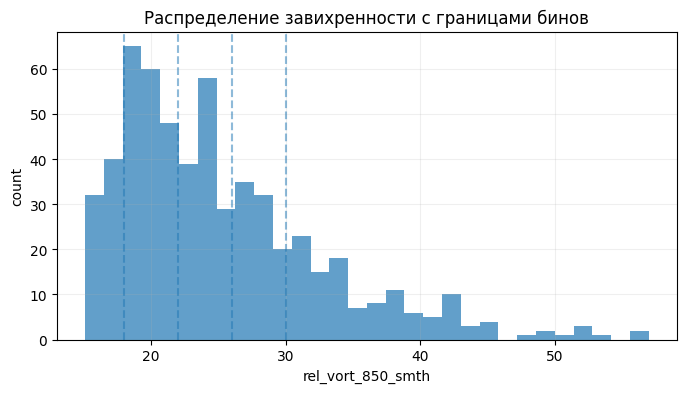

In [8]:
# ячейка 5b
# диагностика: бины завихренности

vort_values = metadata_ml["rel_vort_850_smth"].values

print(
    f"rel_vort_850_smth: min={vort_values.min():.2f}, "
    f"max={vort_values.max():.2f}, "
    f"mean={vort_values.mean():.2f}, "
    f"std={vort_values.std():.2f}"
)

proposed_edges = np.array([-np.inf, 18, 22, 26, 30, np.inf])
proposed_labels = ["<18", "18-22", "22-26", "26-30", ">=30"]

bin_idx = np.digitize(vort_values, proposed_edges) - 1
bin_idx = np.clip(bin_idx, 0, len(proposed_edges) - 2)
counts = np.bincount(bin_idx, minlength=len(proposed_labels))

print("\nраспределение по предложенным бинам:")

for label, c in zip(proposed_labels, counts):
    bar = "#" * int(50 * c / max(counts.sum(), 1))
    print(f"  {label:>10}: {c:>4}  {bar}")

quantile_edges = np.quantile(vort_values, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
print(f"\nдля справки — квантильные границы по 20%: {quantile_edges.round(2)}")

min_count = counts.min()

if min_count < 5:
    print(f"\nВ одном из бинов всего {min_count} сэмплов. Лучше использовать квантильные границы.")
else:
    print(f"\nМинимум сэмплов в бине: {min_count}. Бины адекватны.")

plt.figure(figsize=(8, 4))
plt.hist(vort_values, bins=30, alpha=0.7)

for edge in proposed_edges:
    if np.isfinite(edge):
        plt.axvline(edge, linestyle="--", alpha=0.5)

plt.xlabel("rel_vort_850_smth")
plt.ylabel("count")
plt.title("Распределение завихренности с границами бинов")
plt.grid(alpha=0.2)
plt.show()

In [9]:
# ячейка 6
# модель восстановления сглаженной относительной завихренности

rel_vort_results = run_one_target(
    X=X,
    metadata_ml=metadata_ml,
    target_col="rel_vort_850_smth",
    target_label="сглаженная относительная завихренность",
    target_units="",
    target_bin_edges=np.array([-np.inf, 18, 22, 26, 30, np.inf], dtype=float),
    target_bin_labels=["<18", "18–22", "22–26", "26–30", ">=30"],
)

Output hidden; open in https://colab.research.google.com to view.

### Анализ модели восстановления сглаженной относительной завихренности

Для восстановления сглаженной относительной завихренности на уровне 850 гПа используется та же архитектурная логика, что и для модели давления, где сверточная ветка извлекает признаки облачной структуры из спутникового фрагмента Sentinel-3 SLSTR, отдельная ветка обрабатывает контекстные признаки, после чего оба набора признаков объединяются в регрессионный блок. Поэтому различия в результатах связаны главным образом с другой целевой переменной, а не с принципиально иной архитектурой.

По сравнению с моделью давления задача восстановления завихренности оказалась менее устойчивой. На тестовой выборке модель дает `MAE = 5.89` и `RMSE = 7.87` после калибровки. Это немного лучше бейзлайна среднего значения, у которого `MAE = 6.15` и `RMSE = 8.31`. Однако выигрыш остается небольшим. Коэффициент корреляции Pearson r на test равен `0.374`, что указывает на наличие слабого полезного сигнала, но модель плохо воспроизводит полный диапазон изменчивости завихренности.

Главная проблема модели — сильное сжатие предсказаний к средним значениям. Истинные значения на test изменяются от `15.17` до `55.74`, а калиброванные предсказания лежат только в диапазоне от `21.27` до `28.92`. Стандартное отклонение истинных значений равно `8.30`, а стандартное отклонение калиброванных предсказаний — `1.52`. Значит, модель воспроизводит лишь около `18%` реальной изменчивости целевой переменной. Для модели давления это сжатие тоже было заметно, но для завихренности оно выражено сильнее.

Калибровка задается линейным преобразованием с параметрами `a = 0.705274` и `b = 8.654726`. Она почти убирает среднее смещение прогноза, на valid bias становится близким к нулю, на test составляет около `-0.34`. При этом калибровка дополнительно сжимает разброс предсказаний. Поэтому она улучшает RMSE, но не решает главную проблему — неспособность модели предсказывать высокие значения завихренности.

Побинный анализ показывает, что модель лучше всего работает в центральной части распределения. На test после калибровки ошибка минимальна в диапазонах `22–26` и `26–30`: MAE составляет примерно `1.96` и `2.16`. На низких значениях модель завышает прогноз, а на высоких — резко занижает. Для диапазона `>=30` MAE достигает `13.25`, а средний прогноз равен только `25.76` при истинном среднем `39.00`. Это видно и на графике остатков: при росте истинной завихренности ошибка становится все более отрицательной.

Кривые обучения показывают быстрое снижение train loss и train MAE в первые эпохи. Valid loss и valid MAE улучшаются только в начале, затем выходят на плато и начинают немного колебаться. В исходных единицах valid MAE кратко опускается ниже бейзлайна, после чего держится около `6`. Это говорит о том, что модель быстро извлекает основной слабый сигнал, но дальнейшее обучение почти не улучшает обобщение.

Примеры лучших прогнозов относятся к среднему диапазону завихренности около `23–26`. В этих случаях калиброванный прогноз почти совпадает с истинным значением. Средние по ошибке примеры дают промах около `4.5–4.7`. Худшие прогнозы связаны с высокими значениями завихренности от `42` до `56`: модель предсказывает для них только `24–28`, поэтому ошибки достигают `18–28`.

Итоговый вывод: модель завихренности немного превосходит бейзлайн и улавливает часть связи между спутниковой морфологией и целевой переменной. Но ее предсказания слишком сильно стянуты к среднему диапазону. Восстановление высоких значений завихренности по одному ИК-фрагменту оказывается особенно проблемным. Для улучшения результата нужны дополнительные примеры интенсивных случаев, более явные физические признаки и, вероятно, подключение информации о динамическом окружении циклона.

## Обзор результатов рабты моделей

In [10]:
# ячейка 7
# обзор датасета: характеристики, интересные случаи и снимки

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 1. подготовка таблицы для обзора

overview_df = metadata_ml.copy().reset_index(drop=True)

if "sample_index" not in overview_df.columns:
    overview_df["sample_index"] = np.arange(len(overview_df))

overview_df["obs_datetime"] = pd.to_datetime(overview_df["obs_datetime"], errors="coerce")
overview_df["month"] = overview_df["obs_datetime"].dt.month
overview_df["abs_lat"] = overview_df["lat"].abs()

overview_df["slp"] = pd.to_numeric(overview_df["slp"], errors="coerce")
overview_df["rel_vort_850_smth"] = pd.to_numeric(overview_df["rel_vort_850_smth"], errors="coerce")
overview_df["raw_bt_mean"] = pd.to_numeric(overview_df.get("raw_bt_mean", np.nan), errors="coerce")
overview_df["raw_bt_std"] = pd.to_numeric(overview_df.get("raw_bt_std", np.nan), errors="coerce")
overview_df["raw_bt_range"] = pd.to_numeric(overview_df.get("raw_bt_range", np.nan), errors="coerce")

overview_summary = pd.DataFrame(
    {
        "показатель": [
            "число снимков",
            "число уникальных циклонов",
            "период наблюдений",
            "диапазон давления, гПа",
            "среднее давление, гПа",
            "диапазон завихренности",
            "средняя завихренность",
            "широтный диапазон",
            "долготный диапазон",
            "среднее число снимков на циклон",
            "максимальное число снимков на один циклон",
        ],
        "значение": [
            len(overview_df),
            overview_df["ID"].nunique(),
            f"{overview_df['obs_datetime'].min()} — {overview_df['obs_datetime'].max()}",
            f"{overview_df['slp'].min():.2f} — {overview_df['slp'].max():.2f}",
            f"{overview_df['slp'].mean():.2f}",
            f"{overview_df['rel_vort_850_smth'].min():.3f} — {overview_df['rel_vort_850_smth'].max():.3f}",
            f"{overview_df['rel_vort_850_smth'].mean():.3f}",
            f"{overview_df['lat'].min():.2f} — {overview_df['lat'].max():.2f}",
            f"{overview_df['lon'].min():.2f} — {overview_df['lon'].max():.2f}",
            f"{overview_df.groupby('ID').size().mean():.2f}",
            int(overview_df.groupby("ID").size().max()),
        ],
    }
)

display(overview_summary)

# 2. распределения ключевых характеристик

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(overview_df["slp"], bins=30)
axes[0, 0].set_title("Распределение давления", fontsize=12)
axes[0, 0].set_xlabel("давление, гПа")
axes[0, 0].set_ylabel("число снимков")
axes[0, 0].grid(alpha=0.2)

axes[0, 1].hist(overview_df["rel_vort_850_smth"], bins=30)
axes[0, 1].set_title("Распределение сглаженной относительной завихренности", fontsize=12)
axes[0, 1].set_xlabel("завихренность")
axes[0, 1].set_ylabel("число снимков")
axes[0, 1].grid(alpha=0.2)

axes[1, 0].scatter(
    overview_df["slp"],
    overview_df["rel_vort_850_smth"],
    s=18,
    alpha=0.65,
)
axes[1, 0].set_title("Связь давления и завихренности", fontsize=12)
axes[1, 0].set_xlabel("давление, гПа")
axes[1, 0].set_ylabel("завихренность")
axes[1, 0].grid(alpha=0.2)

monthly_counts = overview_df.groupby("month").size().reindex(range(1, 13), fill_value=0)

axes[1, 1].bar(monthly_counts.index, monthly_counts.values)
axes[1, 1].set_title("Распределение снимков по месяцам", fontsize=12)
axes[1, 1].set_xlabel("месяц")
axes[1, 1].set_ylabel("число снимков")
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 3. функции визуализации снимков

def show_crop(ax, arr):
    img = np.asarray(arr).squeeze()

    vmin = np.nanpercentile(img, 2)
    vmax = np.nanpercentile(img, 98)

    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


def make_case_caption(row, case_name):
    return (
        f"{case_name}\n"
        f"ID: {row['ID']} | step: {int(row['step'])}\n"
        f"{row['obs_datetime']:%Y-%m-%d %H:%M}\n"
        f"давление: {row['slp']:.1f} гПа\n"
        f"завихренность: {row['rel_vort_850_smth']:.2f}\n"
        f"lat: {row['lat']:.2f} | lon: {row['lon']:.2f}"
    )


def make_sequence_caption(row):
    return (
        f"step {int(row['step'])}\n"
        f"{row['obs_datetime']:%m-%d %H:%M}\n"
        f"slp: {row['slp']:.1f} гПа\n"
        f"vort: {row['rel_vort_850_smth']:.2f}"
    )


def add_caption(ax, text, fontsize=9):
    ax.axis("off")
    ax.text(
        0.5,
        0.98,
        text,
        ha="center",
        va="top",
        fontsize=fontsize,
        linespacing=1.25,
        transform=ax.transAxes,
    )


def get_row_by_index(idx):
    return overview_df.loc[int(idx)].copy()


# 4. подбор разных содержательных случаев

median_slp = overview_df["slp"].median()
median_vort = overview_df["rel_vort_850_smth"].median()

case_specs = [
    {
        "case": "минимальное давление",
        "index": overview_df["slp"].idxmin(),
    },
    {
        "case": "максимальное давление",
        "index": overview_df["slp"].idxmax(),
    },
    {
        "case": "максимальная завихренность",
        "index": overview_df["rel_vort_850_smth"].idxmax(),
    },
    {
        "case": "минимальная завихренность",
        "index": overview_df["rel_vort_850_smth"].idxmin(),
    },
    {
        "case": "типичный случай по давлению",
        "index": (overview_df["slp"] - median_slp).abs().idxmin(),
    },
    {
        "case": "типичный случай по завихренности",
        "index": (overview_df["rel_vort_850_smth"] - median_vort).abs().idxmin(),
    },
]

if overview_df["raw_bt_std"].notna().any():
    case_specs.extend(
        [
            {
                "case": "самый высокий контраст снимка",
                "index": overview_df["raw_bt_std"].idxmax(),
            },
            {
                "case": "самый низкий контраст снимка",
                "index": overview_df["raw_bt_std"].idxmin(),
            },
        ]
    )

used_indices = set()
unique_case_specs = []

for item in case_specs:
    idx = int(item["index"])

    if idx not in used_indices:
        used_indices.add(idx)
        unique_case_specs.append(item)


case_table = []

for item in unique_case_specs:
    row = get_row_by_index(item["index"])

    case_table.append(
        {
            "случай": item["case"],
            "sample_index": int(row["sample_index"]),
            "ID": row["ID"],
            "step": int(row["step"]),
            "datetime": row["obs_datetime"],
            "lat": row["lat"],
            "lon": row["lon"],
            "slp": row["slp"],
            "rel_vort_850_smth": row["rel_vort_850_smth"],
            "raw_bt_mean": row.get("raw_bt_mean", np.nan),
            "raw_bt_std": row.get("raw_bt_std", np.nan),
        }
    )

case_table = pd.DataFrame(case_table)

display(case_table)

# 5. визуализация интересных случаев

n_cases = len(unique_case_specs)
n_cols = 4
n_block_rows = int(np.ceil(n_cases / n_cols))

fig = plt.figure(figsize=(4.2 * n_cols, 5.8 * n_block_rows))
gs = GridSpec(
    nrows=n_block_rows * 2,
    ncols=n_cols,
    height_ratios=sum(([4.0, 1.55] for _ in range(n_block_rows)), []),
    hspace=0.06,
    wspace=0.04,
)

fig.suptitle(
    "Разные случаи полярных циклонов в обучающей выборке",
    fontsize=15,
    y=0.995,
)

for j, item in enumerate(unique_case_specs):
    block_row = j // n_cols
    col = j % n_cols

    row = get_row_by_index(item["index"])
    sample_index = int(row["sample_index"])

    ax_img = fig.add_subplot(gs[block_row * 2, col])
    show_crop(ax_img, X[sample_index])

    ax_txt = fig.add_subplot(gs[block_row * 2 + 1, col])
    add_caption(ax_txt, make_case_caption(row, item["case"]), fontsize=8.8)

for j in range(n_cases, n_block_rows * n_cols):
    block_row = j // n_cols
    col = j % n_cols

    ax_img = fig.add_subplot(gs[block_row * 2, col])
    ax_img.axis("off")

    ax_txt = fig.add_subplot(gs[block_row * 2 + 1, col])
    ax_txt.axis("off")

plt.subplots_adjust(top=0.94, bottom=0.03, left=0.02, right=0.98)
plt.show()


# 6. циклоны с самым большим числом снимков

track_counts = (
    overview_df
    .groupby("ID")
    .agg(
        n_images=("sample_index", "size"),
        first_time=("obs_datetime", "min"),
        last_time=("obs_datetime", "max"),
        slp_min=("slp", "min"),
        slp_max=("slp", "max"),
        vort_min=("rel_vort_850_smth", "min"),
        vort_max=("rel_vort_850_smth", "max"),
        lat_min=("lat", "min"),
        lat_max=("lat", "max"),
        lon_min=("lon", "min"),
        lon_max=("lon", "max"),
    )
    .reset_index()
    .sort_values(["n_images", "slp_min"], ascending=[False, True])
)

display(track_counts.head(10))


# 7. временные последовательности для нескольких циклонов

def show_cyclone_sequence(cyclone_id, max_images=8):
    cyclone_df = (
        overview_df[overview_df["ID"].astype(str) == str(cyclone_id)]
        .sort_values(["obs_datetime", "step", "sample_index"])
        .reset_index(drop=True)
    )

    if cyclone_df.empty:
        return

    full_track = cyclone_df.copy()

    if len(cyclone_df) > max_images:
        take_idx = np.linspace(0, len(cyclone_df) - 1, max_images).round().astype(int)
        cyclone_df = cyclone_df.iloc[take_idx].reset_index(drop=True)

    n = len(cyclone_df)
    n_cols = min(4, n)
    n_block_rows = int(np.ceil(n / n_cols))

    fig = plt.figure(figsize=(4.2 * n_cols, 5.3 * n_block_rows))

    gs = GridSpec(
        nrows=n_block_rows * 2,
        ncols=n_cols,
        height_ratios=sum(([4.0, 1.2] for _ in range(n_block_rows)), []),
        hspace=0.06,
        wspace=0.04,
    )

    fig.suptitle(
        (
            f"Последовательность снимков для циклона ID {cyclone_id}\n"
            f"снимков: {len(full_track)}, "
            f"давление: {full_track['slp'].min():.1f}–{full_track['slp'].max():.1f} гПа, "
            f"завихренность: {full_track['rel_vort_850_smth'].min():.2f}–{full_track['rel_vort_850_smth'].max():.2f}"
        ),
        fontsize=14,
        y=0.995,
    )

    for j, row in cyclone_df.iterrows():
        block_row = j // n_cols
        col = j % n_cols

        sample_index = int(row["sample_index"])

        ax_img = fig.add_subplot(gs[block_row * 2, col])
        show_crop(ax_img, X[sample_index])

        ax_txt = fig.add_subplot(gs[block_row * 2 + 1, col])
        add_caption(ax_txt, make_sequence_caption(row), fontsize=8.8)

    for j in range(n, n_block_rows * n_cols):
        block_row = j // n_cols
        col = j % n_cols

        ax_img = fig.add_subplot(gs[block_row * 2, col])
        ax_img.axis("off")

        ax_txt = fig.add_subplot(gs[block_row * 2 + 1, col])
        ax_txt.axis("off")

    plt.subplots_adjust(top=0.90, bottom=0.03, left=0.02, right=0.98)
    plt.show()


top_sequence_ids = track_counts.head(3)["ID"].tolist()

for cyclone_id in top_sequence_ids:
    show_cyclone_sequence(cyclone_id, max_images=8)

Output hidden; open in https://colab.research.google.com to view.

### Итоговый обзор выборки, моделей и последовательностей ПЦ

Итоговая выборка включает 578 спутниковых фрагментов Sentinel-3 SLSTR, связанных с 209 уникальными полярными циклонами за период с 12 января по 31 декабря 2020 г. Диапазон давления составляет 957.08-1021.23 гПа, среднее значение — 989.36 гПа. Диапазон сглаженной относительной завихренности на уровне 850 гПа составляет 15.096-56.956, среднее значение — 25.213. В среднем на один циклон приходится 2.77 снимка, максимальная длина последовательности составляет 9 снимков.

Обзор крайних и типичных случаев показывает, что в выборке представлены разные состояния ПЦ. В нее входят глубокие циклоны с давлением около 957 гПа, слабые случаи с давлением выше 1020 гПа, события с высокой завихренностью до 56.956, а также сцены с разной контрастностью облачного поля. Это важно для интерпретации моделей, поскольку спутниковые фрагменты неоднородны, часть сцен содержит хорошо выраженную вихревую структуру, часть отражает менее организованную или частично читаемую облачность.

Для восстановления давления и сглаженной относительной завихренности использовалась единая архитектурная логика. Сверточная часть модели извлекает признаки из спутникового изображения, отдельный блок обрабатывает контекстные признаки, после чего признаки объединяются и подаются в регрессионную часть. Различия в качестве связаны главным образом с разной физической природой целевых переменных и распределением значений в выборке.

Качество моделей сравнивалось с простой контрольной моделью среднего значения. Такая модель не использует спутниковое изображение, координаты, дату или признаки облачной структуры. Она всем наблюдениям присваивает одно и то же значение — среднее значение целевой переменной. Такое сравнение показывает, извлекает ли нейронная сеть полезную информацию из снимков и контекстных признаков. Если ошибка нейросети ниже ошибки простой контрольной модели, значит модель использует часть информации из данных. Если ошибки близки, качество восстановления остается ограниченным.

Модель давления после калибровки на тестовой выборке дает `MAE = 8.22` гПа, `RMSE = 10.79` гПа и `Pearson r = 0.246`. Простая контрольная модель среднего значения на test дает `MAE = 8.55` гПа и `RMSE = 11.05` гПа. Улучшение есть, но оно небольшое. Модель лучше работает в центральном диапазоне давления около 980-1000 гПа. На глубоких циклонах она завышает давление, а на высоких значениях — занижает. Это указывает на сжатие прогноза к среднему диапазону.

Модель завихренности после калибровки на test дает `MAE = 5.89`, `RMSE = 7.87` и `Pearson r = 0.374`. Простая контрольная модель среднего значения дает `MAE = 6.15` и `RMSE = 8.31`. По корреляции модель завихренности выглядит немного устойчивее модели давления, но у нее сильнее выражено сжатие амплитуды. Истинные значения завихренности на test изменяются от 15.17 до 55.74, а калиброванные прогнозы лежат только в диапазоне 21.27-28.92. Модель почти не воспроизводит высокие значения завихренности выше 30.

Анализ бинов подтверждает общее ограничение обеих моделей. В центральной части распределения ошибки относительно умеренные. На краях диапазона качество резко снижается. Для давления наиболее проблемны случаи ниже 970 гПа и выше 1000 гПа. Для завихренности наиболее проблемны значения выше 30, где модель систематически занижает прогноз.

Последовательности отдельных циклонов показывают, что данные можно анализировать на событийном уровне. Для циклона `120200217310` доступно 9 снимков с 28 по 29 февраля 2020 г. Давление изменяется в пределах 986.5-993.5 гПа, а завихренность — в пределах 33.59-40.37. Такой пример показывает, что набор может использоваться как короткий временной ряд вдоль трека.

Последовательности для циклонов `120201204060` и `120201208590` особенно важны для анализа завихренности. В обоих случаях доступно по 9 снимков, а завихренность меняется резко внутри одного события. У циклона `120201204060` давление остается в диапазоне 991.1-1001.3 гПа, тогда как завихренность меняется от 23.70 до 55.74. У циклона `120201208590` давление лежит в диапазоне 992.7-1006.4 гПа, а завихренность возрастает от 27.10 до 56.96 и затем снижается до 50.41.

Эти последовательности показывают, что давление и завихренность описывают разные стороны состояния ПЦ. Давление связано с барическим состоянием системы, а завихренность сильнее отражает локальную интенсивность вращения. Поэтому высокая завихренность может наблюдаться без экстремально низкого давления. Это усложняет обучение моделей, похожая облачная морфология может соответствовать разным сочетаниям давления и завихренности.

Визуальные примеры подтверждают это ограничение. На отдельных снимках вихревая структура выражена хорошо, однако количественная амплитуда завихренности по одному ИК-фрагменту восстанавливается плохо. Модель часто возвращает значения около среднего диапазона даже для событий с завихренностью выше 40-50. Это связано с редкостью таких случаев и с косвенной связью между инфракрасной морфологией облачности и динамическими характеристиками циклона.

Итоговый результат можно рассматривать как рабочий экспериментальный контур. Снимки Sentinel-3 SLSTR содержат признаки, связанные с давлением и завихренностью ПЦ, но одного ИК-фрагмента недостаточно для надежного восстановления полного диапазона значений. Для повышения качества нужны расширение выборки, увеличение числа экстремальных случаев, учет стадии развития циклона, использование соседних шагов трека и добавление физических признаков окружающей среды.